In [1]:
!pip install -q ipywidgets
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

try:
    import shap, eli5
except:
    %pip install -q shap eli5
    import shap, eli5

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  libxcomposite1 libxdot4
0 upgraded, 11 newly installed, 0 to remove and 138 not upgraded.
Need to get 2,478 kB of archives.
After this operation, 7,871 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main a

2026-04-28 12:56:50.087743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777381010.384848      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777381010.478179      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777381011.188848      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777381011.188901      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777381011.188904      16 computation_placer.cc:177] computation placer alr

In [2]:
try:
    import tensorflow
    import keras
    import xgboost
    from scikeras.wrappers import KerasClassifier
except:
    !pip install -q -U tensorflow keras xgboost scikeras
    import tensorflow
    import keras
    import xgboost
    from scikeras.wrappers import KerasClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 15.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-cloud-videointelligence 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-cloud-vision 3.12.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 whi

In [3]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    !pip install -q venn-abers cir-model
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

  Preparing metadata (setup.py) ... done


In [4]:
import pydot, shap, eli5

shap.initjs()

In [5]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [6]:
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [7]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools
import shutil

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder, LabelEncoder

import warnings

warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

tensorflow.get_logger().setLevel('ERROR')
warnings.filterwarnings("ignore", message="Setting the random state for TF")

In [8]:
## -- Global Settings --
sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [9]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e4/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/'
    orig = pd.read_csv(ORIG_PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e4 | Irrigation Need/_irrigation_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
          'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {v: i for i, v in enumerate(train[TARGET].unique())}
mapping_r = {i: v for i, v in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 20)
Test shape: (270000, 19)
Original shape: (10000, 20)

Total Numerical: 11
Total Categorical: 8
Total base features: 19


In [10]:
display(train.head())
train.info()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,0
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,0
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,0
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,1
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [11]:
train.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Irrigation_Need
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177,0.446178
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939,0.560178
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000,0.000000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000,0.000000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000,0.000000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000,1.000000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000,2.000000


In [12]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='inferno')

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
Train,341,5223,131,341,2934,6475,19308,701,1935,1466,10110,4,6,4,3,4,4,2,5
Original,341,4751,131,341,2897,5305,9813,701,1937,1470,6843,4,6,4,3,4,4,2,5
Test,341,4963,131,341,2864,6149,14483,700,1922,1452,9338,4,6,4,3,4,4,2,5


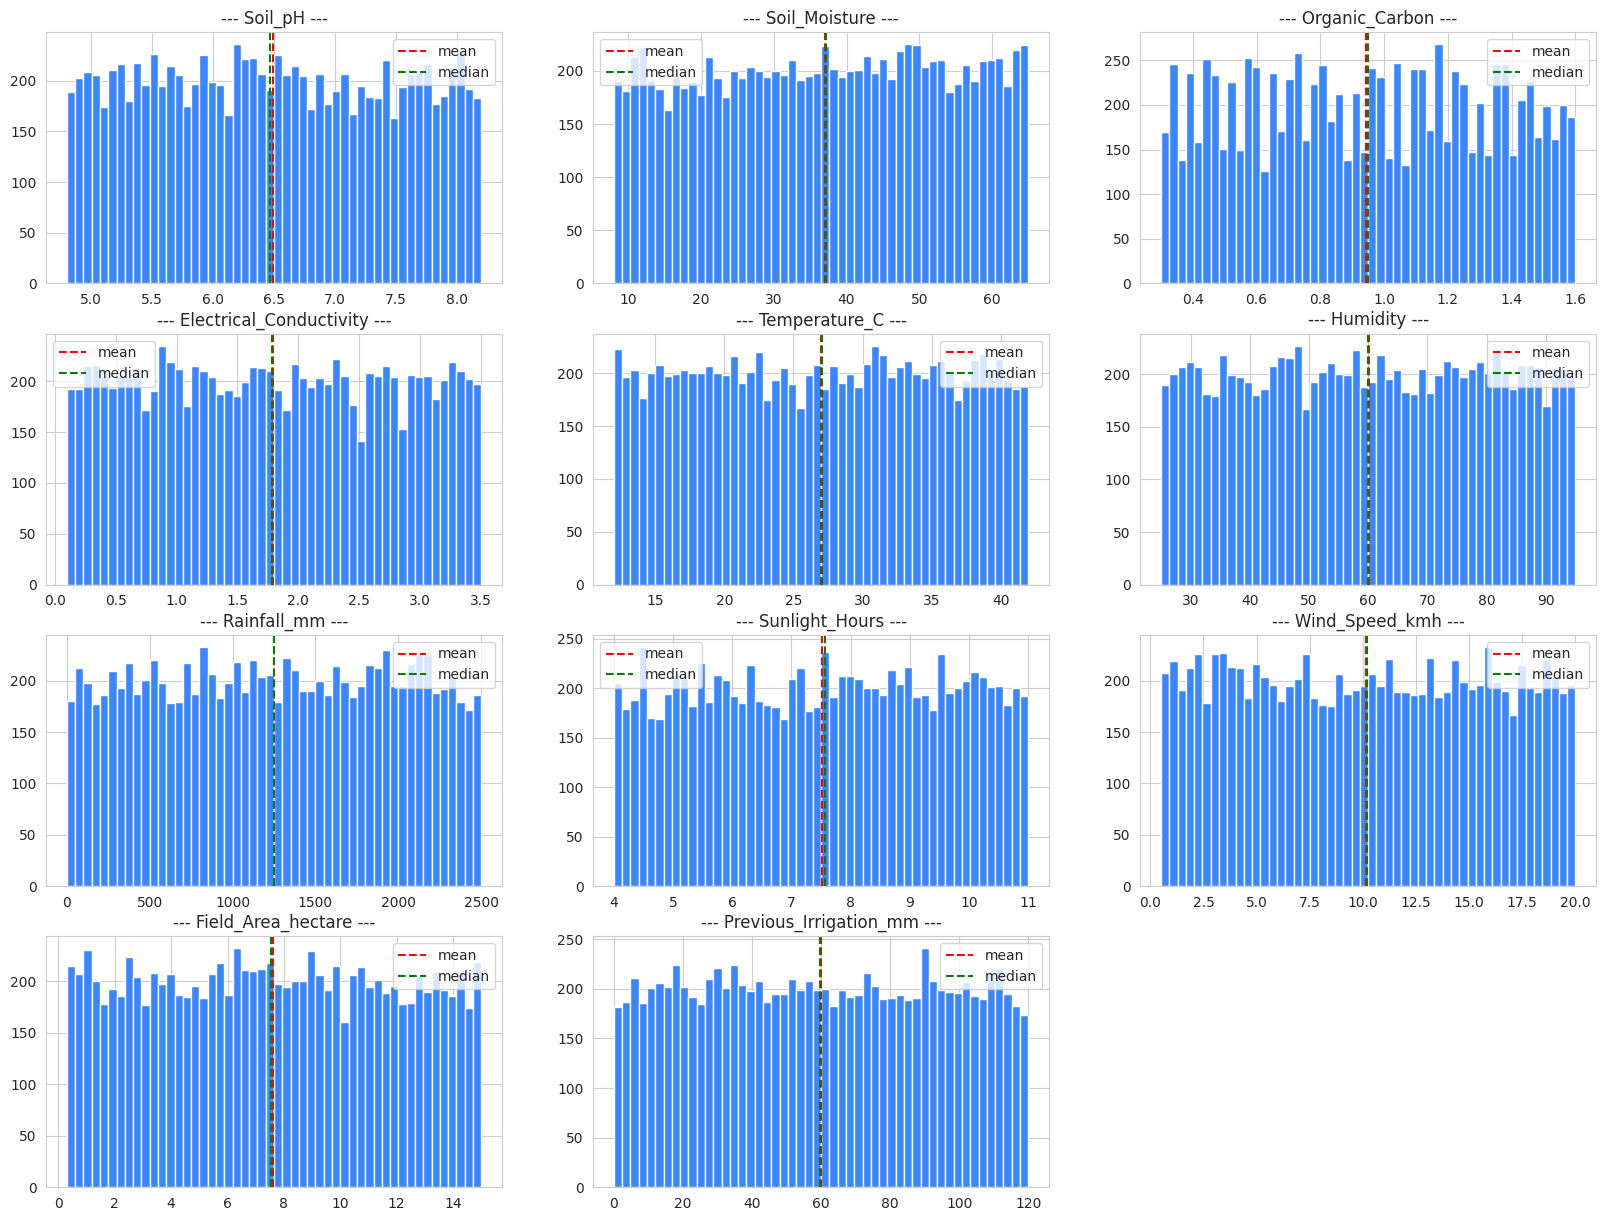

In [13]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()

plt.show()

## FEATURE ENGINEERING

In [14]:
def get_class_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> {label: weight}
    """
    if opt != 'auto':
        class_weights = opt
        return class_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        return class_weights

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        sample_weights = np.array([opt[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    results = balanced_accuracy_score(y_true, pred_labels)
    return results

# def balanced_acc(y_tr, y_pr):
#     y_true = tensorflow.cast(y_tr, tensorflow.int32)
#     # Get predicted labels from probabilities
#     y_pred = tensorflow.cast(tensorflow.argmax(y_pr, axis=1), tensorflow.int32)

#     # Compute confusion matrix
#     cm = tensorflow.math.confusion_matrix(y_true, y_pred)

#     # Recall per class = True Positives / Total Positives (row sums)
#     # Add a tiny epsilon to avoid division by zero
#     diag = tensorflow.cast(tensorflow.linalg.tensor_diag_part(cm), tensorflow.float32)
#     row_sums = tensorflow.cast(tensorflow.reduce_sum(cm, axis=1), tensorflow.float32)

#     recalls = diag / (row_sums + keras.backend.epsilon())

#     # Return average of recalls
#     return tensorflow.reduce_mean(recalls)

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [15]:
# from sklearn.inspection import permutation_importance

# X_1 = train[BASE]
# y_1 = train[TARGET]

# for c in CATS:
#     X_1[c] = X_1[c].factorize()[0]
#     X_1[c] = X_1[c].astype('category')

# x_tr = X_1.sample(frac=0.75, random_state=SEED)
# x_ts = X_1[~X_1.index.isin(x_tr.index)]

# y_tr = y_1.loc[x_tr.index]
# y_ts = y_1.loc[x_ts.index]

# PARAMS = {
#     'loss_function': 'MultiClass',
#     'eval_metric': 'MultiClass',
#     'classes_count': 3,
#     'cat_features': CATS,
#     'random_state': SEED,
#     'verbose': False,
#     'allow_writing_files': False,
#     'thread_count': -1,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# print('Base model training... ', end='')
# model = cgb.CatBoostClassifier(**PARAMS).fit(x_tr, y_tr, sample_weight=get_sample_weights(y_tr, y_1))
# print('Complete!')

# print('Permutation training... ', end='')
# perm_importance = permutation_importance(
#     model,
#     x_ts,
#     y_ts,
#     n_repeats=5,
#     random_state=SEED,
#     scoring='balanced_accuracy',
#     n_jobs=-1,
#     sample_weight=get_sample_weights(y_ts, y_tr),
# )
# print('Complete!')

# importance_df = pd.DataFrame({
#     'feature': BASE,
#     'importance': perm_importance.importances_mean
# }).sort_values(by='importance', ascending=False).reset_index(drop=True)

# top_n = 15

# plt.figure(figsize=(12, 5))
# sns.barplot(data=importance_df.head(top_n), x='importance', y='feature', palette='RdYlGn_r')
# plt.title('Top Predictive Drivers', fontsize=14)

# # plt.tight_layout()
# plt.show()

# importance_df.style.background_gradient(cmap='RdYlGn')

In [16]:
## -- Top/Low features according to PERMUTATION IMPORTANCES --
TOP_COLS = ['Soil_Moisture', 'Temperature_C',
            'Wind_Speed_kmh', 'Rainfall_mm',
            'Mulching_Used', 'Crop_Growth_Stage']

LOW_COLS = [c for c in BASE if c not in TOP_COLS]

print(f"Top Features by PI: {TOP_COLS}")
print(f"Low Features by PI: {LOW_COLS}")

Top Features by PI: ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Rainfall_mm', 'Mulching_Used', 'Crop_Growth_Stage']
Low Features by PI: ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Humidity', 'Sunlight_Hours', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Soil_Type', 'Crop_Type', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']


In [17]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_val   = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     # print(f'OptimalBinning {len(bin_features)}: ', end='')
#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train[new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_val[new_col]   = opt_multi_b.transform(x_val[col].to_numpy(),   metric=metric)
#         x_test[new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_val, x_test

# print('Binning function ready')

In [18]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='cp', # 'cp', 'mip', 'lr'
#     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100,
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [19]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [20]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [21]:
# BIN_TABLES[0].analysis()

In [22]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []
 
round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [23]:
FOUR_VALUES = ['Rainfall_mm']

print(f"\nROUNDING... ", end='')
for col in FOUR_VALUES:
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nCREATING E_BINS... ", end='')
    # for b in [400]: # 100, 500, 1000
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [1000]: # 100, 500, 1000
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Rainfall_mm_round_-2, Rainfall_mm_round_-1, Rainfall_mm_round_0, 
DIGITS... Rainfall_mm_digit_-3, Rainfall_mm_digit_-2, Rainfall_mm_digit_-1, Rainfall_mm_digit_0, Rainfall_mm_digit_1, Rainfall_mm_digit_2, 
✅ Total ROUNDS: 3
✅ Total DIGITS: 6
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [24]:
THREE_VALUES = ['Previous_Irrigation_mm']

for col in THREE_VALUES:
    print(f"\nROUNDING... ", end='')
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [500]: # 50, 100, 400
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Previous_Irrigation_mm_round_-2, Previous_Irrigation_mm_round_-1, Previous_Irrigation_mm_round_0, 
DIGITS... Previous_Irrigation_mm_digit_-2, Previous_Irrigation_mm_digit_-1, Previous_Irrigation_mm_digit_0, Previous_Irrigation_mm_digit_1, Previous_Irrigation_mm_digit_2, 
✅ Total ROUNDS: 5
✅ Total DIGITS: 11
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [25]:
TWO_VALUES = ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh'] + \
             ['Humidity', 'Sunlight_Hours', 'Field_Area_hectare']

for col in TWO_VALUES:
    print(f"\nROUNDING... ", end='')
    for r in [-1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [-1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Soil_Moisture_round_-1, Soil_Moisture_round_0, Soil_Moisture_round_1, 
DIGITS... Soil_Moisture_digit_-1, Soil_Moisture_digit_0, Soil_Moisture_digit_1, Soil_Moisture_digit_2, 
ROUNDING... Temperature_C_round_-1, Temperature_C_round_0, Temperature_C_round_1, 
DIGITS... Temperature_C_digit_-1, Temperature_C_digit_0, Temperature_C_digit_1, Temperature_C_digit_2, 
ROUNDING... Wind_Speed_kmh_round_-1, Wind_Speed_kmh_round_0, Wind_Speed_kmh_round_1, 
DIGITS... Wind_Speed_kmh_digit_-1, Wind_Speed_kmh_digit_0, Wind_Speed_kmh_digit_1, Wind_Speed_kmh_digit_2, 
ROUNDING... Humidity_round_-1, Humidity_round_0, Humidity_round_1, 
DIGITS... Humidity_digit_-1, Humidity_digit_0, Humidity_digit_1, Humidity_digit_2, 
ROUNDING... Sunlight_Hours_round_-1, Sunlight_Hours_round_0, Sunlight_Hours_round_1, 
DIGITS... Sunlight_Hours_digit_-1, Sunlight_Hours_digit_0, Sunlight_Hours_digit_1, Sunlight_Hours_digit_2, 
ROUNDING... Field_Area_hectare_round_-1, Field_Area_hectare_round_0, Field_Area_hecta

In [26]:
ONE_VALUE = ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity']

for col in ONE_VALUE:
    print(f"\nROUNDING... ", end='')
    for r in [0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Soil_pH_round_0, Soil_pH_round_1, 
DIGITS... Soil_pH_digit_0, Soil_pH_digit_1, Soil_pH_digit_2, 
ROUNDING... Organic_Carbon_round_0, Organic_Carbon_round_1, 
DIGITS... Organic_Carbon_digit_0, Organic_Carbon_digit_1, Organic_Carbon_digit_2, 
ROUNDING... Electrical_Conductivity_round_0, Electrical_Conductivity_round_1, 
DIGITS... Electrical_Conductivity_digit_0, Electrical_Conductivity_digit_1, Electrical_Conductivity_digit_2, 
✅ Total ROUNDS: 27
✅ Total DIGITS: 44
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [27]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: ['Previous_Irrigation_mm_round_-2', 'Sunlight_Hours_round_-1', 'Organic_Carbon_round_1']


In [28]:
def add_frequency_condition(df1, cols, thresh=5):
    df = df1.copy()

    for c in cols:
        v_counts = df[c].value_counts()
        to_replace = v_counts[v_counts <= thresh].index
        df[c] = np.where(df[c].isin(to_replace), -1, df[c])

    return df

for df in [train, test, orig]:
    df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

print(f"Frequency threshold imputed!")

Frequency threshold imputed!


In [29]:
## -- BINARY FORMULA --
def add_FE_formula(df1):
    df = df1.copy()

    # 4 Boolean numeric features based on threshold insights
    df['soil_lt_25']  = (df['Soil_Moisture'] < 25).astype('int8')  # <25
    df['temp_gt_30']  = (df['Temperature_C'] > 30).astype('int8')  # >30
    df['rain_lt_300'] = (df['Rainfall_mm'] < 300).astype('int8')   # <300
    df['wind_gt_10']  = (df['Wind_Speed_kmh'] > 10).astype('int8') # >10
    return df

train = add_FE_formula(train)
test  = add_FE_formula(test)
orig  = add_FE_formula(orig)

FORMULA_FLAGS = train.columns.tolist()[-4:]
print(f"Formula flags: {FORMULA_FLAGS}")


## -- LOGIT FORMULA --
for df_ in [train, test]:
    df = pd.get_dummies(df_, columns=CATS, drop_first=False)

    df_['logit(P(y=Low))'] = 16.3173 + (-11.0237 * df["soil_lt_25"]) + (-5.8559 * df["temp_gt_30"]) + (-10.8500 * df["rain_lt_300"]) + (-5.8284 * df["wind_gt_10"]) + (-5.4155 * df["Crop_Growth_Stage_Flowering"]) + (5.5073 * df["Crop_Growth_Stage_Harvest"]) + (5.2299 * df["Crop_Growth_Stage_Sowing"]) + (-5.4617 * df["Crop_Growth_Stage_Vegetative"]) + (-3.0014 * df["Mulching_Used_No"]) + (2.8613 * df["Mulching_Used_Yes"])
    df_['logit(P(y=Medium))'] = 4.6524 + (0.3290 * df["soil_lt_25"]) + (-0.0204 * df["temp_gt_30"]) + (0.1542 * df["rain_lt_300"]) + (0.0841 * df["wind_gt_10"]) + (0.3586 * df["Crop_Growth_Stage_Flowering"]) + (-0.1348 * df["Crop_Growth_Stage_Harvest"]) + (-0.3547 * df["Crop_Growth_Stage_Sowing"]) + (0.3334 * df["Crop_Growth_Stage_Vegetative"]) + (0.1883 * df["Mulching_Used_No"]) + (0.0142 * df["Mulching_Used_Yes"])
    df_['logit(P(y=High))'] = -20.9697 + (10.6947 * df["soil_lt_25"]) + (5.8763 * df["temp_gt_30"]) + (10.6958 * df["rain_lt_300"]) + (5.7444 * df["wind_gt_10"]) + (5.0569 * df["Crop_Growth_Stage_Flowering"]) + (-5.3725 * df["Crop_Growth_Stage_Harvest"]) + (-4.8752 * df["Crop_Growth_Stage_Sowing"]) + (5.1283 * df["Crop_Growth_Stage_Vegetative"]) + (2.8131 * df["Mulching_Used_No"]) + (-2.8755 * df["Mulching_Used_Yes"])

LOGIT_COLS = ['logit(P(y=Low))', 'logit(P(y=Medium))', 'logit(P(y=High))']
print(f"Formula logit: {LOGIT_COLS}\n")

train[FORMULA_FLAGS+LOGIT_COLS].head()

Formula flags: ['soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10']
Formula logit: ['logit(P(y=Low))', 'logit(P(y=Medium))', 'logit(P(y=High))']



,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High))
0,0,0,0,1,12.7174,4.5701,-17.2874
1,0,0,0,0,13.7169,5.0000,-18.7169
2,0,0,0,0,13.7169,5.0000,-18.7169
3,1,0,0,0,2.7394,5.3542,-8.0936
4,0,0,0,1,12.7174,4.5701,-17.2874


In [30]:
INTER = []

for c1, c2 in tqdm(list(itertools.combinations(TOP_COLS, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str)  + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str)  + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str)  + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str)  + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str)  + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str)  + '_' + orig[c2].astype(str)
    INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/15 [00:00<?, ?it/s]

One-to-Many:   0%|          | 0/78 [00:00<?, ?it/s]

Total Interaction Features: 93


In [31]:
# train[LOGIT_COLS].nunique()

In [32]:
# ## -- Arithmetic interaction --
# for df in [train, test, orig]:
#     df['_MonthlyCharges_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
#     df['_TotalCharges_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
#     df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_tenure'] + 1e-6)).astype('float32')
#     df['_TotalCharges_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
#     df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

# ARITHMETIC = ['_MonthlyCharges_TotalCharges', '_TotalCharges_tenure',
#               '_Monthly_to_avg_ratio', '_TotalCharges_MonthlyCharges', '_tenure_sq']

# train[ARITHMETIC].head(3)

In [33]:
# ## -- Cyclic encoding --
# CYCLICS = []

# for col in ['MonthlyCharges', 'TotalCharges']:
#     for p in [12, 30]:
#         n_s = f'{col}_sin_{p}'
#         n_c = f'{col}_cos_{p}'
#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')

#         test[n_s] = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')

#         orig[n_s] = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')

#         CYCLICS += [n_s, n_c]

# print(f"Cylcic Features created: {len(CYCLICS)}")
# train[CYCLICS].head(3)

In [34]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCreate frequencies... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)

# print(f"✅ Total frequency features: {len(NUMS_FREQ)}")

In [35]:
# ## -- CREATE LOG TRANSFORMED FEATURES --
# for df in [train, test, orig]:
#     df['log_MonthlyCharges'] = np.log(df['MonthlyCharges'])
#     df['log_TotalCharges'] = np.log(df['TotalCharges'])

# LOG_FEEATURES = ['log_MonthlyCharges', 'log_TotalCharges']

# plt.figure(figsize=(18, 4))
# for i, col in enumerate(LOG_FEEATURES):
#     plt.subplot(1, len(LOG_FEEATURES), i+1)
#     plt.hist(orig[col], bins=50)
#     plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
#     plt.title(f'{col}')
#     plt.legend()

# plt.show()

In [36]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the
#         global mean. If 'auto', an empirical Bayes estimate is used.

#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'

#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)

#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups

#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)

#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [37]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [38]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+ROUNDS+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [39]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in BASE:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [40]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [41]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 190


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Rainfall_mm_round_-2,Rainfall_mm_round_-1,Rainfall_mm_round_0,Rainfall_mm_digit_-3,Rainfall_mm_digit_-2,Rainfall_mm_digit_-1,Rainfall_mm_digit_0,Rainfall_mm_digit_1,Rainfall_mm_digit_2,Previous_Irrigation_mm_round_-1,Previous_Irrigation_mm_round_0,Previous_Irrigation_mm_digit_-2,Previous_Irrigation_mm_digit_-1,Previous_Irrigation_mm_digit_0,Previous_Irrigation_mm_digit_1,Previous_Irrigation_mm_digit_2,Soil_Moisture_round_-1,Soil_Moisture_round_0,Soil_Moisture_round_1,Soil_Moisture_digit_-1,Soil_Moisture_digit_0,Soil_Moisture_digit_1,Soil_Moisture_digit_2,Temperature_C_round_-1,Temperature_C_round_0,Temperature_C_round_1,Temperature_C_digit_-1,Temperature_C_digit_0,Temperature_C_digit_1,Temperature_C_digit_2,Wind_Speed_kmh_round_-1,Wind_Speed_kmh_round_0,Wind_Speed_kmh_round_1,Wind_Speed_kmh_digit_-1,Wind_Speed_kmh_digit_0,Wind_Speed_kmh_digit_1,Wind_Speed_kmh_digit_2,Humidity_round_-1,Humidity_round_0,Humidity_round_1,Humidity_digit_-1,Humidity_digit_0,Humidity_digit_1,Humidity_digit_2,Sunlight_Hours_round_0,Sunlight_Hours_round_1,Sunlight_Hours_digit_-1,Sunlight_Hours_digit_0,Sunlight_Hours_digit_1,Sunlight_Hours_digit_2,Field_Area_hectare_round_-1,Field_Area_hectare_round_0,Field_Area_hectare_round_1,Field_Area_hectare_digit_-1,Field_Area_hectare_digit_0,Field_Area_hectare_digit_1,Field_Area_hectare_digit_2,Soil_pH_round_0,Soil_pH_round_1,Soil_pH_digit_0,Soil_pH_digit_1,Soil_pH_digit_2,Organic_Carbon_round_0,Organic_Carbon_digit_0,Organic_Carbon_digit_1,Organic_Carbon_digit_2,Electrical_Conductivity_round_0,Electrical_Conductivity_round_1,Electrical_Conductivity_digit_0,Electrical_Conductivity_digit_1,Electrical_Conductivity_digit_2,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High)),Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Bi_Soil_Moisture-|-Soil_pH,Bi_Soil_Moisture-|-Organic_Carbon,Bi_Soil_Moisture-|-Electrical_Conductivity,Bi_Soil_Moisture-|-Humidity,Bi_Soil_Moisture-|-Sunlight_Hours,Bi_Soil_Moisture-|-Field_Area_hectare,Bi_Soil_Moisture-|-Previous_Irrigation_mm,Bi_Soil_Moisture-|-Soil_Type,Bi_Soil_Moisture-|-Crop_Type,Bi_Soil_Moisture-|-Season,Bi_Soil_Moisture-|-Irrigation_Type,Bi_Soil_Moisture-|-Water_Source,Bi_Soil_Moisture-|-Region,Bi_Temperature_C-|-Soil_pH,Bi_Temperature_C-|-Organic_Carbon,Bi_Temperature_C-|-Electrical_Conductivity,Bi_Temperature_C-|-Humidity,Bi_Temperature_C-|-Sunlight_Hours,Bi_Temperature_C-|-Field_Area_hectare,Bi_Temperature_C-|-Previous_Irrigation_mm,Bi_Temperature_C-|-Soil_Type,Bi_Temperature_C-|-Crop_Type,Bi_Temperature_C-|-Season,Bi_Temperature_C-|-Irrigation_Type,Bi_Temperature_C-|-Water_Source,Bi_Temperature_C-|-Region,Bi_Wind_Speed_kmh-|-Soil_pH,Bi_Wind_Speed_kmh-|-Organic_Carbon,Bi_Wind_Speed_kmh-|-Electrical_Conductivity,Bi_Wind_Speed_kmh-|-Humidity,Bi_Wind_Speed_kmh-|-Sunlight_Hours,Bi_Wind_Speed_kmh-|-Field_Area_hectare,Bi_Wind_Speed_kmh-|-Previous_Irrigation_mm,Bi_Wind_Speed_kmh-|-Soil_Type,Bi_Wind_Speed_kmh-|-Crop_Type,Bi_Wind_Speed_kmh-|-Season,Bi_Wind_Speed_kmh-|-Irrigation_Type,Bi_Wind_Speed_kmh-|-Water_Source,Bi_Wind_Speed_kmh-|-Region,Bi_Rainfall_mm-|-Soil_pH,Bi_Rainfall_mm-|-Organic_Carbon,Bi_Rainfall_mm-|-Electrical_Conductivity,Bi_Rainfall_mm-|-Humidity,Bi_Rainfall_mm-|-Sunlight_Hours,Bi_Rainfall_

In [42]:
## -- Ohe-Hot encode CATS --
combine = pd.concat([train[FEATURES], test[FEATURES]])
combine_ohe = pd.get_dummies(combine, columns=CATS, dtype='int8', drop_first=False)

train_enc = combine_ohe[:len(train)]
test  = combine_ohe[-len(test):]

train = pd.concat([train_enc, train[TARGET]], axis=1)

print(f'One-Hot Encoding complete!\nExpanded Features: {combine_ohe.shape[1]}')

combine_ohe.head(3)

One-Hot Encoding complete!
Expanded Features: 214


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Rainfall_mm_round_-2,Rainfall_mm_round_-1,Rainfall_mm_round_0,Rainfall_mm_digit_-3,Rainfall_mm_digit_-2,Rainfall_mm_digit_-1,Rainfall_mm_digit_0,Rainfall_mm_digit_1,Rainfall_mm_digit_2,Previous_Irrigation_mm_round_-1,Previous_Irrigation_mm_round_0,Previous_Irrigation_mm_digit_-2,Previous_Irrigation_mm_digit_-1,Previous_Irrigation_mm_digit_0,Previous_Irrigation_mm_digit_1,Previous_Irrigation_mm_digit_2,Soil_Moisture_round_-1,Soil_Moisture_round_0,Soil_Moisture_round_1,Soil_Moisture_digit_-1,Soil_Moisture_digit_0,Soil_Moisture_digit_1,Soil_Moisture_digit_2,Temperature_C_round_-1,Temperature_C_round_0,Temperature_C_round_1,Temperature_C_digit_-1,Temperature_C_digit_0,Temperature_C_digit_1,Temperature_C_digit_2,Wind_Speed_kmh_round_-1,Wind_Speed_kmh_round_0,Wind_Speed_kmh_round_1,Wind_Speed_kmh_digit_-1,Wind_Speed_kmh_digit_0,Wind_Speed_kmh_digit_1,Wind_Speed_kmh_digit_2,Humidity_round_-1,Humidity_round_0,Humidity_round_1,Humidity_digit_-1,Humidity_digit_0,Humidity_digit_1,Humidity_digit_2,Sunlight_Hours_round_0,Sunlight_Hours_round_1,Sunlight_Hours_digit_-1,Sunlight_Hours_digit_0,Sunlight_Hours_digit_1,Sunlight_Hours_digit_2,Field_Area_hectare_round_-1,Field_Area_hectare_round_0,Field_Area_hectare_round_1,Field_Area_hectare_digit_-1,Field_Area_hectare_digit_0,Field_Area_hectare_digit_1,Field_Area_hectare_digit_2,Soil_pH_round_0,Soil_pH_round_1,Soil_pH_digit_0,Soil_pH_digit_1,Soil_pH_digit_2,Organic_Carbon_round_0,Organic_Carbon_digit_0,Organic_Carbon_digit_1,Organic_Carbon_digit_2,Electrical_Conductivity_round_0,Electrical_Conductivity_round_1,Electrical_Conductivity_digit_0,Electrical_Conductivity_digit_1,Electrical_Conductivity_digit_2,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High)),Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Bi_Soil_Moisture-|-Soil_pH,Bi_Soil_Moisture-|-Organic_Carbon,Bi_Soil_Moisture-|-Electrical_Conductivity,Bi_Soil_Moisture-|-Humidity,Bi_Soil_Moisture-|-Sunlight_Hours,Bi_Soil_Moisture-|-Field_Area_hectare,Bi_Soil_Moisture-|-Previous_Irrigation_mm,Bi_Soil_Moisture-|-Soil_Type,Bi_Soil_Moisture-|-Crop_Type,Bi_Soil_Moisture-|-Season,Bi_Soil_Moisture-|-Irrigation_Type,Bi_Soil_Moisture-|-Water_Source,Bi_Soil_Moisture-|-Region,Bi_Temperature_C-|-Soil_pH,Bi_Temperature_C-|-Organic_Carbon,Bi_Temperature_C-|-Electrical_Conductivity,Bi_Temperature_C-|-Humidity,Bi_Temperature_C-|-Sunlight_Hours,Bi_Temperature_C-|-Field_Area_hectare,Bi_Temperature_C-|-Previous_Irrigation_mm,Bi_Temperature_C-|-Soil_Type,Bi_Temperature_C-|-Crop_Type,Bi_Temperature_C-|-Season,Bi_Temperature_C-|-Irrigation_Type,Bi_Temperature_C-|-Water_Source,Bi_Temperature_C-|-Region,Bi_Wind_Speed_kmh-|-Soil_pH,Bi_Wind_Speed_kmh-|-Organic_Carbon,Bi_Wind_Speed_kmh-|-Electrical_Conductivity,Bi_Wind_Speed_kmh-|-Humidity,Bi_Wind_Speed_kmh-|-Sunlight_Hours,Bi_Wind_Speed_kmh-|-Field_Area_hectare,Bi_Wind_Speed_kmh-|-Previous_Irrigation_mm,Bi_Wind_Speed_kmh-|-Soil_Type,Bi_Wind_Speed_kmh-|-Crop_Type,Bi_Wind_Speed_kmh-|-Season,Bi_Wind_Speed_kmh-|-Irrigation_Type,Bi_Wind_Speed_kmh-|-Water_Source,Bi_Wind_Speed_kmh-|-Region,Bi_Rainfall_mm-|-Soil_pH,Bi_Rainfall_mm-|-Organic_Carbon,Bi_Rainfall_mm-|-Electrical_Conductivity,Bi_Rainfall_mm-|-Humidity,Bi_Rainfall_mm-|-Sunlight_Hours,Bi_Rainfall_mm-|-Field_Area_hectare,Bi_Rainfall_mm-|-Previous_Irrigation_mm,Bi_Rainfall_mm-|-Soil_Type,Bi_Rainfall_mm-|-Cro

In [43]:
## -- Ohe-Hot encode DIGITS --
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]

combine = pd.concat([train[FEATURES], test[FEATURES]])
combine_ohe = pd.get_dummies(combine, columns=DIGITS, dtype='int8', drop_first=False)

train_enc = combine_ohe[:len(train)]
test  = combine_ohe[-len(test):]

train = pd.concat([train_enc, train[TARGET]], axis=1)

print(f'One-Hot Encoding complete!\nExpanded Features: {combine_ohe.shape[1]}')
combine_ohe.head(3)

One-Hot Encoding complete!
Expanded Features: 540


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Rainfall_mm_round_-2,Rainfall_mm_round_-1,Rainfall_mm_round_0,Previous_Irrigation_mm_round_-1,Previous_Irrigation_mm_round_0,Soil_Moisture_round_-1,Soil_Moisture_round_0,Soil_Moisture_round_1,Temperature_C_round_-1,Temperature_C_round_0,Temperature_C_round_1,Wind_Speed_kmh_round_-1,Wind_Speed_kmh_round_0,Wind_Speed_kmh_round_1,Humidity_round_-1,Humidity_round_0,Humidity_round_1,Sunlight_Hours_round_0,Sunlight_Hours_round_1,Field_Area_hectare_round_-1,Field_Area_hectare_round_0,Field_Area_hectare_round_1,Soil_pH_round_0,Soil_pH_round_1,Organic_Carbon_round_0,Electrical_Conductivity_round_0,Electrical_Conductivity_round_1,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High)),Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Bi_Soil_Moisture-|-Soil_pH,Bi_Soil_Moisture-|-Organic_Carbon,Bi_Soil_Moisture-|-Electrical_Conductivity,Bi_Soil_Moisture-|-Humidity,Bi_Soil_Moisture-|-Sunlight_Hours,Bi_Soil_Moisture-|-Field_Area_hectare,Bi_Soil_Moisture-|-Previous_Irrigation_mm,Bi_Soil_Moisture-|-Soil_Type,Bi_Soil_Moisture-|-Crop_Type,Bi_Soil_Moisture-|-Season,Bi_Soil_Moisture-|-Irrigation_Type,Bi_Soil_Moisture-|-Water_Source,Bi_Soil_Moisture-|-Region,Bi_Temperature_C-|-Soil_pH,Bi_Temperature_C-|-Organic_Carbon,Bi_Temperature_C-|-Electrical_Conductivity,Bi_Temperature_C-|-Humidity,Bi_Temperature_C-|-Sunlight_Hours,Bi_Temperature_C-|-Field_Area_hectare,Bi_Temperature_C-|-Previous_Irrigation_mm,Bi_Temperature_C-|-Soil_Type,Bi_Temperature_C-|-Crop_Type,Bi_Temperature_C-|-Season,Bi_Temperature_C-|-Irrigation_Type,Bi_Temperature_C-|-Water_Source,Bi_Temperature_C-|-Region,Bi_Wind_Speed_kmh-|-Soil_pH,Bi_Wind_Speed_kmh-|-Organic_Carbon,Bi_Wind_Speed_kmh-|-Electrical_Conductivity,Bi_Wind_Speed_kmh-|-Humidity,Bi_Wind_Speed_kmh-|-Sunlight_Hours,Bi_Wind_Speed_kmh-|-Field_Area_hectare,Bi_Wind_Speed_kmh-|-Previous_Irrigation_mm,Bi_Wind_Speed_kmh-|-Soil_Type,Bi_Wind_Speed_kmh-|-Crop_Type,Bi_Wind_Speed_kmh-|-Season,Bi_Wind_Speed_kmh-|-Irrigation_Type,Bi_Wind_Speed_kmh-|-Water_Source,Bi_Wind_Speed_kmh-|-Region,Bi_Rainfall_mm-|-Soil_pH,Bi_Rainfall_mm-|-Organic_Carbon,Bi_Rainfall_mm-|-Electrical_Conductivity,Bi_Rainfall_mm-|-Humidity,Bi_Rainfall_mm-|-Sunlight_Hours,Bi_Rainfall_mm-|-Field_Area_hectare,Bi_Rainfall_mm-|-Previous_Irrigation_mm,Bi_Rainfall_mm-|-Soil_Type,Bi_Rainfall_mm-|-Crop_Type,Bi_Rainfall_mm-|-Season,Bi_Rainfall_mm-|-Irrigation_Type,Bi_Rainfall_mm-|-Water_Source,Bi_Rainfall_mm-|-Region,Bi_Mulching_Used-|-Soil_pH,Bi_Mulching_Used-|-Organic_Carbon,Bi_Mulching_Used-|-Electrical_Conductivity,Bi_Mulching_Used-|-Humidity,Bi_Mulching_Used-|-Sunlight_Hours,Bi_Mulching_Used-|-Field_Area_hectare,Bi_Mulching_Used-|-Previous_Irrigation_mm,Bi_Mulching_Used-|-Soil_Type,Bi_Mulching_Used-|-Crop_Type,Bi_Mulching_Used-|-Season,Bi_Mulching_Used-|-Irrigation_Type,Bi_Mulching_Used-|-Water_Source,Bi_Mulching_Used-|-Region,Bi_Crop_Growth_Stage-|-Soil_pH,Bi_Crop_Growth_Stage-|-Organic_Carbon,Bi_Crop_Growth_Stage-|-Electrical_Conductivity,Bi_Crop_Growth_Stage-|-Humidity,Bi_Crop_Growth_Stage-|-Sunlight_Hours,Bi_Crop_Growth_Stage-|-Field_Area_hectare,Bi_Crop_Growth_Stage-|-Previous_Irrigation_mm,Bi_Crop_Growth_Stage-|-Soil_Type,Bi_Crop_Growth_Stage-|-Crop_Type,Bi_Crop_Growth_Stage-|-Season,Bi_Crop_Growth_Stage-|-Irrigation_Type,Bi_Crop_Growth_Stage-|-Water_Source,Bi_Crop_Growth_Stage-|-Region,Soil_Type_Clay,Soil

In [44]:
## -- Ohe-Hot encode ROUNDS --
# FEATURES = [c for c in train.columns if c not in ['id', TARGET]]

# combine = pd.concat([train[FEATURES], test[FEATURES]])
# combine_ohe = pd.get_dummies(combine, columns=ROUNDS, dtype='int8', drop_first=False)

# train_enc = combine_ohe[:len(train)]
# test  = combine_ohe[-len(test):]

# train = pd.concat([train_enc, train[TARGET]], axis=1)

# print(f'One-Hot Encoding complete!\nExpanded Features: {combine_ohe.shape[1]}')

In [45]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
NEW_CATS = [c for c in FEATURES if col.endswith('_')]
NEW_NUMS = [c for c in FEATURES if col.startswith('_')]

print('Total Features:', len(FEATURES))
print('Total Cat Cols:', len(NEW_CATS))
print('Total Num Cols:', len(NEW_NUMS))

train.head(3)

Total Features: 540
Total Cat Cols: 0
Total Num Cols: 0


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Rainfall_mm_round_-2,Rainfall_mm_round_-1,Rainfall_mm_round_0,Previous_Irrigation_mm_round_-1,Previous_Irrigation_mm_round_0,Soil_Moisture_round_-1,Soil_Moisture_round_0,Soil_Moisture_round_1,Temperature_C_round_-1,Temperature_C_round_0,Temperature_C_round_1,Wind_Speed_kmh_round_-1,Wind_Speed_kmh_round_0,Wind_Speed_kmh_round_1,Humidity_round_-1,Humidity_round_0,Humidity_round_1,Sunlight_Hours_round_0,Sunlight_Hours_round_1,Field_Area_hectare_round_-1,Field_Area_hectare_round_0,Field_Area_hectare_round_1,Soil_pH_round_0,Soil_pH_round_1,Organic_Carbon_round_0,Electrical_Conductivity_round_0,Electrical_Conductivity_round_1,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High)),Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Bi_Soil_Moisture-|-Soil_pH,Bi_Soil_Moisture-|-Organic_Carbon,Bi_Soil_Moisture-|-Electrical_Conductivity,Bi_Soil_Moisture-|-Humidity,Bi_Soil_Moisture-|-Sunlight_Hours,Bi_Soil_Moisture-|-Field_Area_hectare,Bi_Soil_Moisture-|-Previous_Irrigation_mm,Bi_Soil_Moisture-|-Soil_Type,Bi_Soil_Moisture-|-Crop_Type,Bi_Soil_Moisture-|-Season,Bi_Soil_Moisture-|-Irrigation_Type,Bi_Soil_Moisture-|-Water_Source,Bi_Soil_Moisture-|-Region,Bi_Temperature_C-|-Soil_pH,Bi_Temperature_C-|-Organic_Carbon,Bi_Temperature_C-|-Electrical_Conductivity,Bi_Temperature_C-|-Humidity,Bi_Temperature_C-|-Sunlight_Hours,Bi_Temperature_C-|-Field_Area_hectare,Bi_Temperature_C-|-Previous_Irrigation_mm,Bi_Temperature_C-|-Soil_Type,Bi_Temperature_C-|-Crop_Type,Bi_Temperature_C-|-Season,Bi_Temperature_C-|-Irrigation_Type,Bi_Temperature_C-|-Water_Source,Bi_Temperature_C-|-Region,Bi_Wind_Speed_kmh-|-Soil_pH,Bi_Wind_Speed_kmh-|-Organic_Carbon,Bi_Wind_Speed_kmh-|-Electrical_Conductivity,Bi_Wind_Speed_kmh-|-Humidity,Bi_Wind_Speed_kmh-|-Sunlight_Hours,Bi_Wind_Speed_kmh-|-Field_Area_hectare,Bi_Wind_Speed_kmh-|-Previous_Irrigation_mm,Bi_Wind_Speed_kmh-|-Soil_Type,Bi_Wind_Speed_kmh-|-Crop_Type,Bi_Wind_Speed_kmh-|-Season,Bi_Wind_Speed_kmh-|-Irrigation_Type,Bi_Wind_Speed_kmh-|-Water_Source,Bi_Wind_Speed_kmh-|-Region,Bi_Rainfall_mm-|-Soil_pH,Bi_Rainfall_mm-|-Organic_Carbon,Bi_Rainfall_mm-|-Electrical_Conductivity,Bi_Rainfall_mm-|-Humidity,Bi_Rainfall_mm-|-Sunlight_Hours,Bi_Rainfall_mm-|-Field_Area_hectare,Bi_Rainfall_mm-|-Previous_Irrigation_mm,Bi_Rainfall_mm-|-Soil_Type,Bi_Rainfall_mm-|-Crop_Type,Bi_Rainfall_mm-|-Season,Bi_Rainfall_mm-|-Irrigation_Type,Bi_Rainfall_mm-|-Water_Source,Bi_Rainfall_mm-|-Region,Bi_Mulching_Used-|-Soil_pH,Bi_Mulching_Used-|-Organic_Carbon,Bi_Mulching_Used-|-Electrical_Conductivity,Bi_Mulching_Used-|-Humidity,Bi_Mulching_Used-|-Sunlight_Hours,Bi_Mulching_Used-|-Field_Area_hectare,Bi_Mulching_Used-|-Previous_Irrigation_mm,Bi_Mulching_Used-|-Soil_Type,Bi_Mulching_Used-|-Crop_Type,Bi_Mulching_Used-|-Season,Bi_Mulching_Used-|-Irrigation_Type,Bi_Mulching_Used-|-Water_Source,Bi_Mulching_Used-|-Region,Bi_Crop_Growth_Stage-|-Soil_pH,Bi_Crop_Growth_Stage-|-Organic_Carbon,Bi_Crop_Growth_Stage-|-Electrical_Conductivity,Bi_Crop_Growth_Stage-|-Humidity,Bi_Crop_Growth_Stage-|-Sunlight_Hours,Bi_Crop_Growth_Stage-|-Field_Area_hectare,Bi_Crop_Growth_Stage-|-Previous_Irrigation_mm,Bi_Crop_Growth_Stage-|-Soil_Type,Bi_Crop_Growth_Stage-|-Crop_Type,Bi_Crop_Growth_Stage-|-Season,Bi_Crop_Growth_Stage-|-Irrigation_Type,Bi_Crop_Growth_Stage-|-Water_Source,Bi_Crop_Growth_Stage-|-Region,Soil_Type_Clay,Soil

In [46]:
for col in FEATURES:
    if train[col].nunique() == 1:
        print(col)

# ML TRAINING

In [47]:
def build_keras_model(lr, units, shape):
    drop_rate=0.5
    kernel_reg=keras.regularizers.L2(0.0)

    # 2. Create the Sequential model
    model = keras.Sequential([
        keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        # keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        keras.layers.Dense(units[0], 'relu', use_bias=False,
                           kernel_regularizer=kernel_reg),
        keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        keras.layers.Dropout(drop_rate),

        ## -- 2nd Layer --
        keras.layers.Dense(units[1], 'relu', use_bias=False,
                           kernel_regularizer=kernel_reg),
        keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        keras.layers.Dropout(drop_rate),

        ## -- 3rd Layer --
        keras.layers.Dense(units[2], 'relu', use_bias=False,
                           kernel_regularizer=kernel_reg),
        keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        keras.layers.Dropout(drop_rate),

        ## -- Output --
        keras.layers.Dense(len(mapping), activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(lr, weight_decay=None), # 0.02
        # optimizer=keras.optimizers.RMSprop(lr),
        loss=keras.losses.SparseCategoricalCrossentropy(name='loss'),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
        )

    return model

print('⚙️ KERAS MODEL READY⚙️')

⚙️ KERAS MODEL READY⚙️


In [48]:
# ## -- DEFINE TRAINER --
# class TrainerCV:
#     def __init__(
#         self,
#         model_builder, # function(input_shape, batch_size, epochs, learning_rate, **kwargs) -> keras.Model
#         model_name: str,
#         train_df: pd.DataFrame,
#         test_df: pd.DataFrame,
#         features: list,
#         target: str,
#         kf, # e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#         batch_size: int=32,
#         units=[256, 128, 32],
#         epochs: int=10,
#         patience: int=3,
#         activation: str='relu',
#         learning_rate: float=1e-2,
#         eval_metric: str='val_loss',
#         **kwargs
#     ):
#         self.model_builder = model_builder
#         self.model_name = model_name
#         self.train_df = train_df
#         self.test_df = test_df
#         self.features = features
#         self.target = target
#         self.kf = kf
#         self.batch_size = batch_size
#         self.units = units
#         self.epochs = epochs
#         self.patience = patience
#         self.activation = activation
#         self.learning_rate = learning_rate
#         self.eval_metric = eval_metric

#         self.result = None

#     # def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
#     #     # This helper can be extended if you want to apply masks or augmentation.
#     #     return X, y

#     # def _df_to_ds(self, df_full, target, batch_input):
#     #     df = df_full.copy()
#     #     labels = df.pop(target)
#     #     ds = tensorflow.data.Dataset.from_tensor_slices((dict(df), labels))
#     #     ds = ds.batch(batch_input)
#     #     return ds


#     def fit(self):
#         train_df = self.train_df
#         test_df  = self.test_df
#         features = self.features
#         target   = self.target

#         print(f"\n========== Starting Cross-Validation for {self.model_name} ==========")
#         start = time()

#         num_classes = train_df[target].nunique()

#         X = train_df[features]
#         y = train_df[target]

#         self.oof_preds = np.zeros((len(train_df), num_classes))
#         self.test_preds = np.zeros((len(test_df), num_classes))
#         self.oof_scores = []

#         self.calib_oof_preds = np.zeros((len(train_df), num_classes))
#         self.calib_test_preds = np.zeros((len(test_df), num_classes))
#         self.calib_fold_scores = []

#         self.fold_histories = []

#         strategy = tensorflow.distribute.MirroredStrategy()
#         GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
#         print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

#         for idx, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
#             print(f"\n***** FOLD {idx+1}/{self.kf.n_splits} *****")
#             print('-'*50)

#             ## -- Split data for the current fold --
#             X_train = train_df.loc[train_idx, features]
#             y_train = train_df.loc[train_idx, target]
#             X_valid = train_df.loc[val_idx, features]
#             y_valid = train_df.loc[val_idx, target]

#             X_test  = test_df[features].copy()

#             ## -- Target Encoding -- 
#             TE_COLS = ROUNDS + INTER  #+ DIGITS#
#             print(f" • Target Encoding {len(TE_COLS)} features... ")
#             te_enc = TargetEncoder(target_type='multiclass', cv=5, random_state=SEED)
#             train_enc = te_enc.fit_transform(X_train[TE_COLS], y_train).astype('float32')
#             val_enc   = te_enc.transform(X_valid[TE_COLS]).astype('float32')
#             test_enc  = te_enc.transform(X_test[TE_COLS]).astype('float32')
#             ## -- Assign names to TE columns --
#             rename_cols = [f'TE_{col}' for col in train_enc.columns]
#             train_enc.columns = rename_cols
#             test_enc.columns  = rename_cols
#             val_enc.columns   = rename_cols
#             ## -- Merge TE features back to dataset, drop old features --
#             X_train = pd.concat([X_train, train_enc], axis=1).drop(columns=TE_COLS).copy()
#             X_valid = pd.concat([X_valid,   val_enc], axis=1).drop(columns=TE_COLS).copy()
#             X_test  = pd.concat([X_test,  test_enc],  axis=1).drop(columns=TE_COLS).copy()

#             ## -- Standardize Numerics --
#             scale_cols = ['Rainfall_mm', 'Previous_Irrigation_mm'] #+ LOGIT_COLS
#             for col in scale_cols:
#                 scaler = StandardScaler()
#                 X_train[col] = scaler.fit_transform(X_train[[col]])
#                 X_valid[col] = scaler.transform(X_valid[[col]])
#                 X_test[col]  = scaler.transform(X_test[[col]])

#             ## -- Define callbacks --
#             monitor_metric = 'val_accuracy' # 'val_loss' 'val_balanced_accuracy'

#             callbacks = [
#                 keras.callbacks.EarlyStopping(
#                     monitor=monitor_metric,
#                     # mode=mode_monitor,
#                     patience=self.patience,
#                     restore_best_weights=True,
#                 ),
#                 # keras.callbacks.ReduceLROnPlateau( # -> dynamic adjust lr
#                 #     monitor=monitor_metric,
#                 #     factor=0.5,
#                 #     patience=5,
#                 #     min_lr=1e-6,
#                 #     verbose=1
#                 # ),
#                 keras.callbacks.ModelCheckpoint( # -> save model
#                     filepath=f"{CHECKPOINT}best_model.model.keras",
#                     monitor=monitor_metric,
#                     save_best_only=True,
#                     # verbose=1
#                 ),
#                 keras.callbacks.ModelCheckpoint( # -> save weights
#                     filepath=f"{CHECKPOINT}best_model.weights.h5",
#                     monitor=monitor_metric,
#                     save_best_only=True,
#                     save_weights_only=True,
#                 ),
#             ]

#             ## -- Build model --
#             print(f' • Training base model {X_train.shape}... ')
#             keras_clf = KerasClassifier(
#                 self.model_builder,
#                 model__lr=self.learning_rate,
#                 model__units=self.units,
#                 model__shape=X_train.shape[1:],
#                 batch_size=GLOBAL_BATCH_SIZE,
#                 # validation_batch_size=10000,
#                 verbose=2,
#                 callbacks=callbacks,
#                 # validation_split=0.0,
#                 shuffle=True,
#                 run_eagerly=False,
#                 epochs=self.epochs,
#                 class_weight=get_class_weights(y_train, y_train),
#                 random_state=SEED,
#             )

#             keras_clf.fit(
#                 X_train, y_train,
#                 validation_data=(X_valid, y_valid),
#                 # sample_weight=get_sample_weights(y_train, y_train)
#             )

#             self.fold_histories.append(keras_clf.history_)

#             ## -- Make predictions --
#             self.oof_preds[val_idx] = keras_clf.predict_proba(X_valid)
#             self.test_preds += keras_clf.predict_proba(X_test)
#             fold_score = balanced_acc(y_valid, self.oof_preds[val_idx])
#             self.oof_scores.append(fold_score)
#             print(f"{YELLOW} • Fold {idx+1} Score: {fold_score:.5f}{RESET}")

#         # keras_clf.summary()

#         ## -- Average test predictions
#         self.test_preds /= self.kf.n_splits

#         ## -- Print final cross-validation results --
#         print("\n==================================================")
#         print(f"Cross-Validation Results for {self.model_name}")
#         print("==================================================")
#         for i, score in enumerate(self.oof_scores):
#             print(f" • FOLD {i+1} Score: {score:.5f}")

#         overall_score = np.round(balanced_acc(y, self.oof_preds), 5)

#         print(f"{'='*40}")
#         print(f"OOF Score: {overall_score}")
#         print(f"AVG Score: {np.mean(self.oof_scores):.5f} ± {np.std(self.oof_scores):.5f}")
#         print(f"{'-'*40}")
#         print(f'{((time() - start) / 60):.2f} mins\n')

#         return {
#             'final_score': overall_score,
#             'scores': self.oof_scores,
#             'oof_preds': self.oof_preds,
#             'test_preds': self.test_preds,
#             'val_data': [X_valid, y_valid],
#             'history': self.fold_histories,
#         }

# print('⚙️ MODEL TRAINER READY ⚙️')

In [49]:
## -- DEFINE TRAINER --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function(input_shape, batch_size, epochs, learning_rate, **kwargs) -> keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kf, # e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        batch_size: int=32,
        units=[256, 128, 32],
        epochs: int=10,
        patience: int=3,
        activation: str='relu',
        learning_rate: float=1e-2,
        eval_metric: str='val_loss',
        calibrator: str=None,
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kf = kf
        self.batch_size = batch_size
        self.units = units
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.learning_rate = learning_rate
        self.eval_metric = eval_metric
        self.calibrator = calibrator

        self.result = None

    # def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
    #     # This helper can be extended if you want to apply masks or augmentation.
    #     return X, y

    # def _df_to_ds(self, df_full, target, batch_input):
    #     df = df_full.copy()
    #     labels = df.pop(target)
    #     ds = tensorflow.data.Dataset.from_tensor_slices((dict(df), labels))
    #     ds = ds.batch(batch_input)
    #     return ds


    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n========== Starting Cross-Validation for {self.model_name} ==========")
        start = time()

        num_classes = train_df[target].nunique()

        X = train_df[features]
        y = train_df[target]

        self.oof_preds = np.zeros((len(train_df), num_classes))
        self.test_preds = np.zeros((len(test_df), num_classes))
        self.oof_scores = []

        self.calib_oof_preds = np.zeros((len(train_df), num_classes))
        self.calib_test_preds = np.zeros((len(test_df), num_classes))
        self.calib_fold_scores = []

        self.fold_histories = []

        strategy = tensorflow.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        for idx, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
            print(f"\n***** FOLD {idx+1}/{self.kf.n_splits} *****")

            ## -- Split data for the current fold --
            X_train = train_df.loc[train_idx, features]
            y_train = train_df.loc[train_idx, target]
            X_valid = train_df.loc[val_idx, features]
            y_valid = train_df.loc[val_idx, target]

            X_test  = test_df[features].copy()

            ## -- Target Encoding -- 
            TE_COLS = ROUNDS + INTER  #+ DIGITS#
            print(f" • Target Encoding {len(TE_COLS)} features... ")
            te_enc = TargetEncoder(target_type='multiclass', cv=5, random_state=SEED)
            train_enc = te_enc.fit_transform(X_train[TE_COLS], y_train).astype('float32')
            val_enc   = te_enc.transform(X_valid[TE_COLS]).astype('float32')
            test_enc  = te_enc.transform(X_test[TE_COLS]).astype('float32')
            ## -- Assign names to TE columns --
            rename_cols = [f'TE_{col}' for col in train_enc.columns]
            train_enc.columns = rename_cols
            test_enc.columns  = rename_cols
            val_enc.columns   = rename_cols
            ## -- Merge TE features back to dataset, drop old features --
            X_train = pd.concat([X_train, train_enc], axis=1).drop(columns=TE_COLS).copy()
            X_valid = pd.concat([X_valid,   val_enc], axis=1).drop(columns=TE_COLS).copy()
            X_test  = pd.concat([X_test,  test_enc],  axis=1).drop(columns=TE_COLS).copy()

            ## -- Standardize Numerics --
            scale_cols = ['Rainfall_mm', 'Previous_Irrigation_mm']
            for col in scale_cols:
                scaler = StandardScaler()
                X_train[col] = scaler.fit_transform(X_train[[col]])
                X_valid[col] = scaler.transform(X_valid[[col]])
                X_test[col]  = scaler.transform(X_test[[col]])

            ## -- Internal Split for Calibration --
            X_base, X_calib, y_base, y_calib = train_test_split(
                X_train, y_train, train_size=0.7, stratify=y_train, random_state=SEED
            )

            ## -- Define callbacks --
            callbacks = [
                keras.callbacks.EarlyStopping(
                    monitor=self.eval_metric,
                    # mode=mode_monitor,
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                keras.callbacks.ReduceLROnPlateau( # -> dynamic adjust lr
                    monitor=self.eval_metric,
                    factor=0.5,
                    patience=5,
                    min_lr=1e-6,
                    verbose=1
                ),
                keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    # verbose=1
                ),
                keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- Build model --
            keras_clf = KerasClassifier(
                self.model_builder,
                model__lr=self.learning_rate,
                model__units=self.units,
                model__shape=X_train.shape[1:],
                batch_size=GLOBAL_BATCH_SIZE,
                # validation_batch_size=10000,
                verbose=2,
                callbacks=callbacks,
                # validation_split=0.0,
                shuffle=True,
                run_eagerly=False,
                epochs=self.epochs,
                class_weight=get_class_weights(y_train, y_train),
                random_state=SEED,
            )

            print(f' • Training base model {X_base.shape}... ')
            keras_clf.fit(
                X_base, y_base,
                validation_data=(X_valid, y_valid),
                # sample_weight=get_sample_weights(y_train, y_train)
            )

            self.fold_histories.append(keras_clf.history_)

            ## -- Make predictions --
            self.oof_preds[val_idx] = keras_clf.predict_proba(X_valid)
            self.test_preds += keras_clf.predict_proba(X_test)
            fold_score = balanced_acc(y_valid, self.oof_preds[val_idx])
            self.oof_scores.append(fold_score)
    
            if self.calibrator == 'isotonic':
                print(f' • Training Isotonic Calibrator {X_calib.shape}... ', end='')
                calib_model = CalibratedClassifierCV(FrozenEstimator(keras_clf), cv=None, 
                                                     method='isotonic', n_jobs=-1)
                calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))
    
                self.calib_oof_preds[val_idx] = calib_model.predict_proba(X_val)
                self.calib_test_preds += calib_model.predict_proba(X_test)
        
                calib_fold_score = balanced_acc(y_valid, self.calib_oof_preds[val_idx])
                self.calib_fold_scores.append(calib_fold_score)
                print(self.calib_oof_preds[val_idx].shape, self.calib_test_preds.shape)
            elif self.calibrator == 'venn_one':
                print(f' • Training Venn-Abers 1-vs-1 {X_calib.shape}... ', end='')
                vao = VennAbersCalibrator() ## Get OOF predictions --
                oof_calib, oof_p0p1 = vao.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                        y_cal=y_calib.to_numpy(),
                                                        p_test=keras_clf.predict_proba(X_valid),
                                                        p0_p1_output=True, va_type='one_vs_one')
                self.calib_oof_preds[val_idx] = oof_calib
    
                vat = VennAbersCalibrator() ## Get TEST predictions --
                test_calib, test_p0p1 = vat.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                          y_cal=y_calib.to_numpy(),
                                                          p_test=keras_clf.predict_proba(X_test),
                                                          p0_p1_output=True, va_type='one_vs_one')
                self.calib_test_preds += test_calib
    
                calib_fold_score = balanced_acc(y_valid, self.calib_oof_preds[val_idx])
                self.calib_fold_scores.append(calib_fold_score)
                print(oof_calib.shape, test_calib.shape)
            elif self.calibrator == 'venn_all':
                print(f' • Training Venn-Abers 1-vs-all {X_calib.shape}... ', end='')
                
                vao = VennAbersCalibrator() ## Get OOF predictions --
                oof_calib, oof_p0p1 = vao.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                        y_cal=y_calib.to_numpy(),
                                                        p_test=keras_clf.predict_proba(X_valid),
                                                        p0_p1_output=True, va_type='one_vs_all')
                self.calib_oof_preds[val_idx] = oof_calib
    
                vat = VennAbersCalibrator() ## Get TEST predictions --
                test_calib, test_p0p1 = vat.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                          y_cal=y_calib.to_numpy(),
                                                          p_test=keras_clf.predict_proba(X_test),
                                                          p0_p1_output=True, va_type='one_vs_all')
                self.calib_test_preds += test_calib

                calib_fold_score = balanced_acc(y_valid, self.calib_oof_preds[val_idx])
                self.calib_fold_scores.append(calib_fold_score)
                print(oof_calib.shape, test_calib.shape)

            get_base_loss  = log_loss(y_valid, self.oof_preds[val_idx])
            get_calib_loss = log_loss(y_valid, self.calib_oof_preds[val_idx])

            print(f"{YELLOW} • FOLD {idx+1} RESULTS ------------------------------")
            print(f"Balanced_Acc: base -> {fold_score:.5f} | calib -> {calib_fold_score:.5f}")
            print(f'Log_loss:     base -> {get_base_loss:.5f} | calib -> {get_calib_loss:.5f}{RESET}')

        ## -- Average test predictions
        self.test_preds /= self.kf.n_splits
        self.calib_test_preds /= self.kf.n_splits

        ## -- Print final cross-validation results --
        print("\n==================================================")
        print(f"Cross-Validation Results for {self.model_name}")
        print("==================================================")
        for i, score in enumerate(self.oof_scores):
            print(f" • FOLD {i+1} Score: {score:.5f}")

        overall_score = np.round(balanced_acc(y, self.oof_preds), 5)
        calib_overall_score = np.round(balanced_acc(y, self.calib_oof_preds), 5)

        print(f"{'='*40}")
        print(f"OOF:  BASE -> {overall_score} | CALIB -> {calib_overall_score}")
        print(f"{'-'*40}")
        print(f"AVG  Base: {np.mean(self.oof_scores):.5f} ± {np.std(self.oof_scores):.5f}")
        print(f"AVG Calib: {np.mean(self.calib_fold_scores):.5f} ± {np.std(self.calib_fold_scores):.5f}")
        print(f"{'-'*40}")
        print(f"{GREEN}Improved: {calib_overall_score - overall_score:.5f}{RESET}")
        print(f"{'='*40}")
        print(f'{((time() - start) / 60):.2f} mins\n')

        return {
            'final_score': [overall_score, calib_overall_score],
            'scores': [self.oof_scores, self.calib_fold_scores],

            'oof_preds': [self.oof_preds, self.calib_oof_preds if self.calibrator != None else None],
            'test_preds': [self.test_preds, self.calib_test_preds if self.calibrator != None else None],

            'val_data': [X_valid, y_valid, oof_p0p1 if self.calibrator != None else None],
            'history': self.fold_histories,
        }

print('⚙️ MODEL TRAINER READY ⚙️')

⚙️ MODEL TRAINER READY ⚙️


In [50]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Rainfall_mm_round_-2,Rainfall_mm_round_-1,Rainfall_mm_round_0,Previous_Irrigation_mm_round_-1,Previous_Irrigation_mm_round_0,Soil_Moisture_round_-1,Soil_Moisture_round_0,Soil_Moisture_round_1,Temperature_C_round_-1,Temperature_C_round_0,Temperature_C_round_1,Wind_Speed_kmh_round_-1,Wind_Speed_kmh_round_0,Wind_Speed_kmh_round_1,Humidity_round_-1,Humidity_round_0,Humidity_round_1,Sunlight_Hours_round_0,Sunlight_Hours_round_1,Field_Area_hectare_round_-1,Field_Area_hectare_round_0,Field_Area_hectare_round_1,Soil_pH_round_0,Soil_pH_round_1,Organic_Carbon_round_0,Electrical_Conductivity_round_0,Electrical_Conductivity_round_1,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High)),Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Bi_Soil_Moisture-|-Soil_pH,Bi_Soil_Moisture-|-Organic_Carbon,Bi_Soil_Moisture-|-Electrical_Conductivity,Bi_Soil_Moisture-|-Humidity,Bi_Soil_Moisture-|-Sunlight_Hours,Bi_Soil_Moisture-|-Field_Area_hectare,Bi_Soil_Moisture-|-Previous_Irrigation_mm,Bi_Soil_Moisture-|-Soil_Type,Bi_Soil_Moisture-|-Crop_Type,Bi_Soil_Moisture-|-Season,Bi_Soil_Moisture-|-Irrigation_Type,Bi_Soil_Moisture-|-Water_Source,Bi_Soil_Moisture-|-Region,Bi_Temperature_C-|-Soil_pH,Bi_Temperature_C-|-Organic_Carbon,Bi_Temperature_C-|-Electrical_Conductivity,Bi_Temperature_C-|-Humidity,Bi_Temperature_C-|-Sunlight_Hours,Bi_Temperature_C-|-Field_Area_hectare,Bi_Temperature_C-|-Previous_Irrigation_mm,Bi_Temperature_C-|-Soil_Type,Bi_Temperature_C-|-Crop_Type,Bi_Temperature_C-|-Season,Bi_Temperature_C-|-Irrigation_Type,Bi_Temperature_C-|-Water_Source,Bi_Temperature_C-|-Region,Bi_Wind_Speed_kmh-|-Soil_pH,Bi_Wind_Speed_kmh-|-Organic_Carbon,Bi_Wind_Speed_kmh-|-Electrical_Conductivity,Bi_Wind_Speed_kmh-|-Humidity,Bi_Wind_Speed_kmh-|-Sunlight_Hours,Bi_Wind_Speed_kmh-|-Field_Area_hectare,Bi_Wind_Speed_kmh-|-Previous_Irrigation_mm,Bi_Wind_Speed_kmh-|-Soil_Type,Bi_Wind_Speed_kmh-|-Crop_Type,Bi_Wind_Speed_kmh-|-Season,Bi_Wind_Speed_kmh-|-Irrigation_Type,Bi_Wind_Speed_kmh-|-Water_Source,Bi_Wind_Speed_kmh-|-Region,Bi_Rainfall_mm-|-Soil_pH,Bi_Rainfall_mm-|-Organic_Carbon,Bi_Rainfall_mm-|-Electrical_Conductivity,Bi_Rainfall_mm-|-Humidity,Bi_Rainfall_mm-|-Sunlight_Hours,Bi_Rainfall_mm-|-Field_Area_hectare,Bi_Rainfall_mm-|-Previous_Irrigation_mm,Bi_Rainfall_mm-|-Soil_Type,Bi_Rainfall_mm-|-Crop_Type,Bi_Rainfall_mm-|-Season,Bi_Rainfall_mm-|-Irrigation_Type,Bi_Rainfall_mm-|-Water_Source,Bi_Rainfall_mm-|-Region,Bi_Mulching_Used-|-Soil_pH,Bi_Mulching_Used-|-Organic_Carbon,Bi_Mulching_Used-|-Electrical_Conductivity,Bi_Mulching_Used-|-Humidity,Bi_Mulching_Used-|-Sunlight_Hours,Bi_Mulching_Used-|-Field_Area_hectare,Bi_Mulching_Used-|-Previous_Irrigation_mm,Bi_Mulching_Used-|-Soil_Type,Bi_Mulching_Used-|-Crop_Type,Bi_Mulching_Used-|-Season,Bi_Mulching_Used-|-Irrigation_Type,Bi_Mulching_Used-|-Water_Source,Bi_Mulching_Used-|-Region,Bi_Crop_Growth_Stage-|-Soil_pH,Bi_Crop_Growth_Stage-|-Organic_Carbon,Bi_Crop_Growth_Stage-|-Electrical_Conductivity,Bi_Crop_Growth_Stage-|-Humidity,Bi_Crop_Growth_Stage-|-Sunlight_Hours,Bi_Crop_Growth_Stage-|-Field_Area_hectare,Bi_Crop_Growth_Stage-|-Previous_Irrigation_mm,Bi_Crop_Growth_Stage-|-Soil_Type,Bi_Crop_Growth_Stage-|-Crop_Type,Bi_Crop_Growth_Stage-|-Season,Bi_Crop_Growth_Stage-|-Irrigation_Type,Bi_Crop_Growth_Stage-|-Water_Source,Bi_Crop_Growth_Stage-|-Region,Soil_Type_Clay,Soil

In [51]:
gc.collect()

42

In [52]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [53]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [54]:
%%time

FOLDS        = 10
LR           = 0.005
EPOCHS       = 50
PATIENCE     = 5
BATCH_SIZE   = 64
DIMENSIONS   = [900, 256, 128]

valid_metric = 'val_accuracy'

calib_type   = 'venn_all'
version_name = f'keras_V0_{calib_type}_'

kfold = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

trainer = TrainerCV(
    model_builder=build_keras_model,
    model_name=version_name,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kfold,
    batch_size=BATCH_SIZE,
    units=DIMENSIONS,
    activation='relu',
    epochs=EPOCHS,
    patience=PATIENCE,
    learning_rate=LR,
    eval_metric=valid_metric,
    calibrator=calib_type,
)

result = trainer.fit()

load_model = keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")
load_model.summary()


========== Starting Cross-Validation for keras_V0_venn_all_ ==========


2026-04-28 13:01:29.448413: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


⚙️ Number of devices: 1

***** FOLD 1/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 13:07:49.100407: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 13:09:25.391773: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 103s - 17ms/step - accuracy: 0.9530 - loss: 0.1612 - val_accuracy: 0.9687 - val_loss: 0.0947 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 96s - 16ms/step - accuracy: 0.9701 - loss: 0.1169 - val_accuracy: 0.9762 - val_loss: 0.0862 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 94s - 15ms/step - accuracy: 0.9734 - loss: 0.1062 - val_accuracy: 0.9773 - val_loss: 0.0840 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9744 - loss: 0.1011 - val_accuracy: 0.9774 - val_loss: 0.0804 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9751 - loss: 0.0980 - val_accuracy: 0.9777 - val_loss: 0.0866 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9761 - loss: 0.0960 - val_accuracy: 0.9815 - val_loss: 0.0679 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9765 - loss: 0.0922 - val_accuracy: 0.9805 - val_loss: 0.0701 - learning_rate: 0.0050
Epoch 8/50
6202/6202 - 93s - 15ms/ste

2026-04-28 13:30:37.873165: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 9s - 9ms/step


2026-04-28 13:30:58.190110: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 19s - 4ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 13:31:19.493326: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 13:31:32.539182: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 13:33:11.323073: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 13:33:26.858211: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 16s - 4ms/step
(63000, 3) (270000, 3)
 • FOLD 1 RESULTS ------------------------------
Balanced_Acc: base -> 0.97680 | calib -> 0.97476
Log_loss:     base -> 0.06526 | calib -> 0.05592

***** FOLD 2/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 13:42:39.225080: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 13:44:10.329393: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 99s - 16ms/step - accuracy: 0.9537 - loss: 0.1590 - val_accuracy: 0.9781 - val_loss: 0.0755 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9703 - loss: 0.1148 - val_accuracy: 0.9830 - val_loss: 0.0624 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9738 - loss: 0.1051 - val_accuracy: 0.9838 - val_loss: 0.0618 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 91s - 15ms/step - accuracy: 0.9756 - loss: 0.0993 - val_accuracy: 0.9825 - val_loss: 0.0640 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 89s - 14ms/step - accuracy: 0.9760 - loss: 0.0949 - val_accuracy: 0.9805 - val_loss: 0.0648 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 96s - 16ms/step - accuracy: 0.9764 - loss: 0.0916 - val_accuracy: 0.9761 - val_loss: 0.0730 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 94s - 15ms/step - accuracy: 0.9765 - loss: 0.0905 - val_accuracy: 0.9812 - val_loss: 0.0640 - learning_rate: 0.0050
Epoch 8/50

Epoch 8: ReduceLROnPlateau

2026-04-28 13:55:10.809894: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 13:55:20.155560: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 20s - 5ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 13:55:43.007738: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 13:55:55.673034: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 13:57:51.528256: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 13:58:06.190472: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 18s - 4ms/step
(63000, 3) (270000, 3)
 • FOLD 2 RESULTS ------------------------------
Balanced_Acc: base -> 0.97461 | calib -> 0.97282
Log_loss:     base -> 0.06184 | calib -> 0.05212

***** FOLD 3/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 14:07:44.295596: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 14:09:16.554484: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 100s - 16ms/step - accuracy: 0.9528 - loss: 0.1616 - val_accuracy: 0.9799 - val_loss: 0.0731 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 100s - 16ms/step - accuracy: 0.9695 - loss: 0.1192 - val_accuracy: 0.9733 - val_loss: 0.0889 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 101s - 16ms/step - accuracy: 0.9737 - loss: 0.1063 - val_accuracy: 0.9838 - val_loss: 0.0611 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 97s - 16ms/step - accuracy: 0.9745 - loss: 0.1028 - val_accuracy: 0.9833 - val_loss: 0.0621 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 142s - 23ms/step - accuracy: 0.9755 - loss: 0.0975 - val_accuracy: 0.9823 - val_loss: 0.0659 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 139s - 22ms/step - accuracy: 0.9756 - loss: 0.0966 - val_accuracy: 0.9841 - val_loss: 0.0597 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 92s - 15ms/step - accuracy: 0.9768 - loss: 0.0928 - val_accuracy: 0.9845 - val_loss: 0.0579 - learning_rate: 0.0050
Epoch 8/50
6202/6202 - 93s - 15ms

2026-04-28 14:31:35.366344: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 14:31:44.637772: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 21s - 5ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 14:32:09.794099: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 14:32:22.390476: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 14:33:21.921594: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 14:33:38.752421: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 17s - 4ms/step
(63000, 3) (270000, 3)
 • FOLD 3 RESULTS ------------------------------
Balanced_Acc: base -> 0.97550 | calib -> 0.97260
Log_loss:     base -> 0.05850 | calib -> 0.05242

***** FOLD 4/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 14:42:33.461830: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 14:44:11.226698: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 105s - 17ms/step - accuracy: 0.9526 - loss: 0.1611 - val_accuracy: 0.9824 - val_loss: 0.0705 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9693 - loss: 0.1177 - val_accuracy: 0.9852 - val_loss: 0.0593 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 93s - 15ms/step - accuracy: 0.9723 - loss: 0.1077 - val_accuracy: 0.9846 - val_loss: 0.0620 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 95s - 15ms/step - accuracy: 0.9741 - loss: 0.1024 - val_accuracy: 0.9851 - val_loss: 0.0594 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 95s - 15ms/step - accuracy: 0.9752 - loss: 0.0981 - val_accuracy: 0.9844 - val_loss: 0.0597 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 146s - 23ms/step - accuracy: 0.9754 - loss: 0.0973 - val_accuracy: 0.9843 - val_loss: 0.0579 - learning_rate: 0.0050
Epoch 7/50

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
6202/6202 - 98s - 16ms/step - accuracy: 0.9759 - loss: 0.0943 - val_accuracy: 0.9851 - 

2026-04-28 14:54:38.533798: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 14:54:47.792094: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 23s - 5ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 14:55:15.008046: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 12s - 5ms/step


2026-04-28 14:55:28.395538: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 14:57:12.513141: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 14:57:30.840132: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 18s - 4ms/step
(63000, 3) (270000, 3)
 • FOLD 4 RESULTS ------------------------------
Balanced_Acc: base -> 0.96971 | calib -> 0.96686
Log_loss:     base -> 0.05928 | calib -> 0.05495

***** FOLD 5/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 15:06:58.025890: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 15:08:37.921963: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 108s - 17ms/step - accuracy: 0.9512 - loss: 0.1660 - val_accuracy: 0.9806 - val_loss: 0.0732 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 98s - 16ms/step - accuracy: 0.9693 - loss: 0.1199 - val_accuracy: 0.9850 - val_loss: 0.0618 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 141s - 23ms/step - accuracy: 0.9737 - loss: 0.1068 - val_accuracy: 0.9858 - val_loss: 0.0588 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 95s - 15ms/step - accuracy: 0.9745 - loss: 0.1027 - val_accuracy: 0.9857 - val_loss: 0.0571 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 98s - 16ms/step - accuracy: 0.9754 - loss: 0.0989 - val_accuracy: 0.9857 - val_loss: 0.0568 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 103s - 17ms/step - accuracy: 0.9753 - loss: 0.0978 - val_accuracy: 0.9839 - val_loss: 0.0640 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 97s - 16ms/step - accuracy: 0.9763 - loss: 0.0940 - val_accuracy: 0.9856 - val_loss: 0.0570 - learning_rate: 0.0050
Epoch 8/50

Epoch 8: ReduceLROnPlat

2026-04-28 15:20:52.192073: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 15:21:01.801534: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 18s - 4ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 15:21:22.969062: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 15:21:35.474610: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 5ms/step


2026-04-28 15:23:09.903536: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 15:23:25.215407: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 20s - 5ms/step
(63000, 3) (270000, 3)
 • FOLD 5 RESULTS ------------------------------
Balanced_Acc: base -> 0.97552 | calib -> 0.97408
Log_loss:     base -> 0.05879 | calib -> 0.05230

***** FOLD 6/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 15:33:47.463019: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 15:35:26.382631: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 107s - 17ms/step - accuracy: 0.9524 - loss: 0.1622 - val_accuracy: 0.9841 - val_loss: 0.0638 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9695 - loss: 0.1177 - val_accuracy: 0.9793 - val_loss: 0.0737 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 98s - 16ms/step - accuracy: 0.9726 - loss: 0.1081 - val_accuracy: 0.9854 - val_loss: 0.0571 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 97s - 16ms/step - accuracy: 0.9738 - loss: 0.1043 - val_accuracy: 0.9846 - val_loss: 0.0593 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9751 - loss: 0.0999 - val_accuracy: 0.9840 - val_loss: 0.0609 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 100s - 16ms/step - accuracy: 0.9755 - loss: 0.0964 - val_accuracy: 0.9843 - val_loss: 0.0594 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 104s - 17ms/step - accuracy: 0.9760 - loss: 0.0940 - val_accuracy: 0.9830 - val_loss: 0.0627 - learning_rate: 0.0050
Epoch 8/50

Epoch 8: ReduceLROnPlat

2026-04-28 15:47:09.086493: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 15:47:19.153858: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 18s - 4ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 15:47:40.626190: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 15:47:53.934644: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 15:49:03.493063: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 12s - 4ms/step


2026-04-28 15:49:19.487100: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 19s - 5ms/step
(63000, 3) (270000, 3)
 • FOLD 6 RESULTS ------------------------------
Balanced_Acc: base -> 0.97477 | calib -> 0.97140
Log_loss:     base -> 0.05713 | calib -> 0.05283

***** FOLD 7/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 15:58:55.448931: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 16:00:34.178512: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 106s - 17ms/step - accuracy: 0.9514 - loss: 0.1671 - val_accuracy: 0.9688 - val_loss: 0.0988 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 97s - 16ms/step - accuracy: 0.9692 - loss: 0.1190 - val_accuracy: 0.9707 - val_loss: 0.0917 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 101s - 16ms/step - accuracy: 0.9724 - loss: 0.1082 - val_accuracy: 0.9826 - val_loss: 0.0643 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 98s - 16ms/step - accuracy: 0.9743 - loss: 0.1029 - val_accuracy: 0.9841 - val_loss: 0.0599 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 95s - 15ms/step - accuracy: 0.9750 - loss: 0.0981 - val_accuracy: 0.9837 - val_loss: 0.0621 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 95s - 15ms/step - accuracy: 0.9760 - loss: 0.0957 - val_accuracy: 0.9845 - val_loss: 0.0582 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 98s - 16ms/step - accuracy: 0.9763 - loss: 0.0932 - val_accuracy: 0.9823 - val_loss: 0.0645 - learning_rate: 0.0050
Epoch 8/50
6202/6202 - 97s - 16ms/st

2026-04-28 16:35:16.255004: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 5s - 5ms/step


2026-04-28 16:35:28.108107: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 18s - 4ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 16:35:49.717793: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 16:36:02.588424: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 16:37:37.102024: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 13s - 5ms/step


2026-04-28 16:37:53.899389: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 20s - 5ms/step
(63000, 3) (270000, 3)
 • FOLD 7 RESULTS ------------------------------
Balanced_Acc: base -> 0.97549 | calib -> 0.97377
Log_loss:     base -> 0.05521 | calib -> 0.05137

***** FOLD 8/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 16:48:43.058617: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 16:50:19.873205: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 105s - 17ms/step - accuracy: 0.9528 - loss: 0.1616 - val_accuracy: 0.9728 - val_loss: 0.0845 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9702 - loss: 0.1154 - val_accuracy: 0.9847 - val_loss: 0.0623 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 102s - 17ms/step - accuracy: 0.9728 - loss: 0.1058 - val_accuracy: 0.9844 - val_loss: 0.0657 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 100s - 16ms/step - accuracy: 0.9743 - loss: 0.1000 - val_accuracy: 0.9821 - val_loss: 0.0642 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9755 - loss: 0.0959 - val_accuracy: 0.9847 - val_loss: 0.0600 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 98s - 16ms/step - accuracy: 0.9759 - loss: 0.0941 - val_accuracy: 0.9825 - val_loss: 0.0653 - learning_rate: 0.0050
Epoch 7/50

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
6202/6202 - 104s - 17ms/step - accuracy: 0.9758 - loss: 0.0936 - val_accuracy: 0.9842 

2026-04-28 17:00:29.477633: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 17:00:39.752265: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 18s - 4ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 17:01:00.578242: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 17:01:13.744979: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 17:02:47.069432: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 13s - 5ms/step


2026-04-28 17:03:04.796943: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 22s - 5ms/step
(63000, 3) (270000, 3)
 • FOLD 8 RESULTS ------------------------------
Balanced_Acc: base -> 0.97438 | calib -> 0.97086
Log_loss:     base -> 0.06233 | calib -> 0.05294

***** FOLD 9/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 17:13:24.643085: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 17:15:04.916674: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 108s - 17ms/step - accuracy: 0.9524 - loss: 0.1616 - val_accuracy: 0.9764 - val_loss: 0.0823 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9704 - loss: 0.1159 - val_accuracy: 0.9773 - val_loss: 0.0771 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 103s - 17ms/step - accuracy: 0.9736 - loss: 0.1048 - val_accuracy: 0.9776 - val_loss: 0.0813 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9749 - loss: 0.0993 - val_accuracy: 0.9812 - val_loss: 0.0700 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9757 - loss: 0.0961 - val_accuracy: 0.9818 - val_loss: 0.0720 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 100s - 16ms/step - accuracy: 0.9764 - loss: 0.0930 - val_accuracy: 0.9790 - val_loss: 0.0768 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9766 - loss: 0.0925 - val_accuracy: 0.9803 - val_loss: 0.0717 - learning_rate: 0.0050
Epoch 8/50
6202/6202 - 99s - 16ms/s

2026-04-28 17:46:18.276729: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 5s - 5ms/step


2026-04-28 17:46:30.158209: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 19s - 5ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 17:46:52.886640: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 11s - 4ms/step


2026-04-28 17:47:05.489492: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 17:48:30.370676: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 10s - 4ms/step


2026-04-28 17:48:45.091920: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 17s - 4ms/step
(63000, 3) (270000, 3)
 • FOLD 9 RESULTS ------------------------------
Balanced_Acc: base -> 0.97641 | calib -> 0.97225
Log_loss:     base -> 0.05983 | calib -> 0.05243

***** FOLD 10/10 *****
 • Target Encoding 120 features... 
 • Training base model (396900, 780)... 
Epoch 1/50


2026-04-28 17:59:28.201248: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-04-28 18:01:13.737743: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6202/6202 - 114s - 18ms/step - accuracy: 0.9534 - loss: 0.1608 - val_accuracy: 0.9706 - val_loss: 0.1004 - learning_rate: 0.0050
Epoch 2/50
6202/6202 - 103s - 17ms/step - accuracy: 0.9704 - loss: 0.1156 - val_accuracy: 0.9801 - val_loss: 0.0757 - learning_rate: 0.0050
Epoch 3/50
6202/6202 - 138s - 22ms/step - accuracy: 0.9735 - loss: 0.1048 - val_accuracy: 0.9736 - val_loss: 0.0889 - learning_rate: 0.0050
Epoch 4/50
6202/6202 - 102s - 16ms/step - accuracy: 0.9747 - loss: 0.0996 - val_accuracy: 0.9821 - val_loss: 0.0673 - learning_rate: 0.0050
Epoch 5/50
6202/6202 - 100s - 16ms/step - accuracy: 0.9757 - loss: 0.0962 - val_accuracy: 0.9703 - val_loss: 0.0984 - learning_rate: 0.0050
Epoch 6/50
6202/6202 - 104s - 17ms/step - accuracy: 0.9762 - loss: 0.0950 - val_accuracy: 0.9814 - val_loss: 0.0684 - learning_rate: 0.0050
Epoch 7/50
6202/6202 - 99s - 16ms/step - accuracy: 0.9766 - loss: 0.0931 - val_accuracy: 0.9719 - val_loss: 0.0936 - learning_rate: 0.0050
Epoch 8/50
6202/6202 - 97s - 16m

2026-04-28 18:15:22.219609: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 5s - 5ms/step


2026-04-28 18:15:32.932209: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 18s - 4ms/step
 • Training Venn-Abers 1-vs-all (170100, 780)... 

2026-04-28 18:15:54.228462: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 12s - 4ms/step


2026-04-28 18:16:07.780815: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


985/985 - 4s - 4ms/step


2026-04-28 18:17:48.847788: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2658/2658 - 12s - 4ms/step


2026-04-28 18:18:05.155294: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4219/4219 - 19s - 5ms/step
(63000, 3) (270000, 3)
 • FOLD 10 RESULTS ------------------------------
Balanced_Acc: base -> 0.97680 | calib -> 0.97472
Log_loss:     base -> 0.06726 | calib -> 0.05514

Cross-Validation Results for keras_V0_venn_all_
 • FOLD 1 Score: 0.97680
 • FOLD 2 Score: 0.97461
 • FOLD 3 Score: 0.97550
 • FOLD 4 Score: 0.96971
 • FOLD 5 Score: 0.97552
 • FOLD 6 Score: 0.97477
 • FOLD 7 Score: 0.97549
 • FOLD 8 Score: 0.97438
 • FOLD 9 Score: 0.97641
 • FOLD 10 Score: 0.97680
OOF:  BASE -> 0.975 | CALIB -> 0.97241
----------------------------------------
AVG  Base: 0.97500 ± 0.00194
AVG Calib: 0.97241 ± 0.00224
----------------------------------------
Improved: -0.00259
318.57 mins



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 900)            │       702,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 900)            │         3,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │       230,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,906,939 (11.09 MB)

 Trainable params: 968,123 (3.69 MB)

 Non-trainable params: 2,568 (10.03 KB)

 Optimizer params: 1,936,248 (7.39 MB)

CPU times: user 10h 14min 13s, sys: 40min 41s, total: 10h 54min 54s
Wall time: 5h 18min 40s


In [55]:
# ==================================================
#  • FOLD 1 Score: 0.97482 
#  • FOLD 2 Score: 0.97540
#  • FOLD 3 Score: 0.97531
#  • FOLD 4 Score: 0.97364
#  • FOLD 5 Score: 0.97561
# ========================================
# OOF:  BASE -> 0.97496 | CALIB -> 0.97287
# ----------------------------------------
# AVG  Base: 0.97496 ± 0.00071
# AVG Calib: 0.97287 ± 0.00214
# ----------------------------------------
# Improved: -0.00209
# ========================================
# 56.71 mins

In [56]:
# =============================
# OOF Score: 0.97239
# AVG Score: 0.97239 ± 0.00129 
# -----------------------------
# 45.73 mins 

In [57]:
result.keys()

dict_keys(['final_score', 'scores', 'oof_preds', 'test_preds', 'val_data', 'history'])

In [58]:
result['val_data'][-1][0]
np.corrcoef(result['val_data'][-1][0], rowvar=False)

array([[1.        , 0.99998818],
       [0.99998818, 1.        ]])

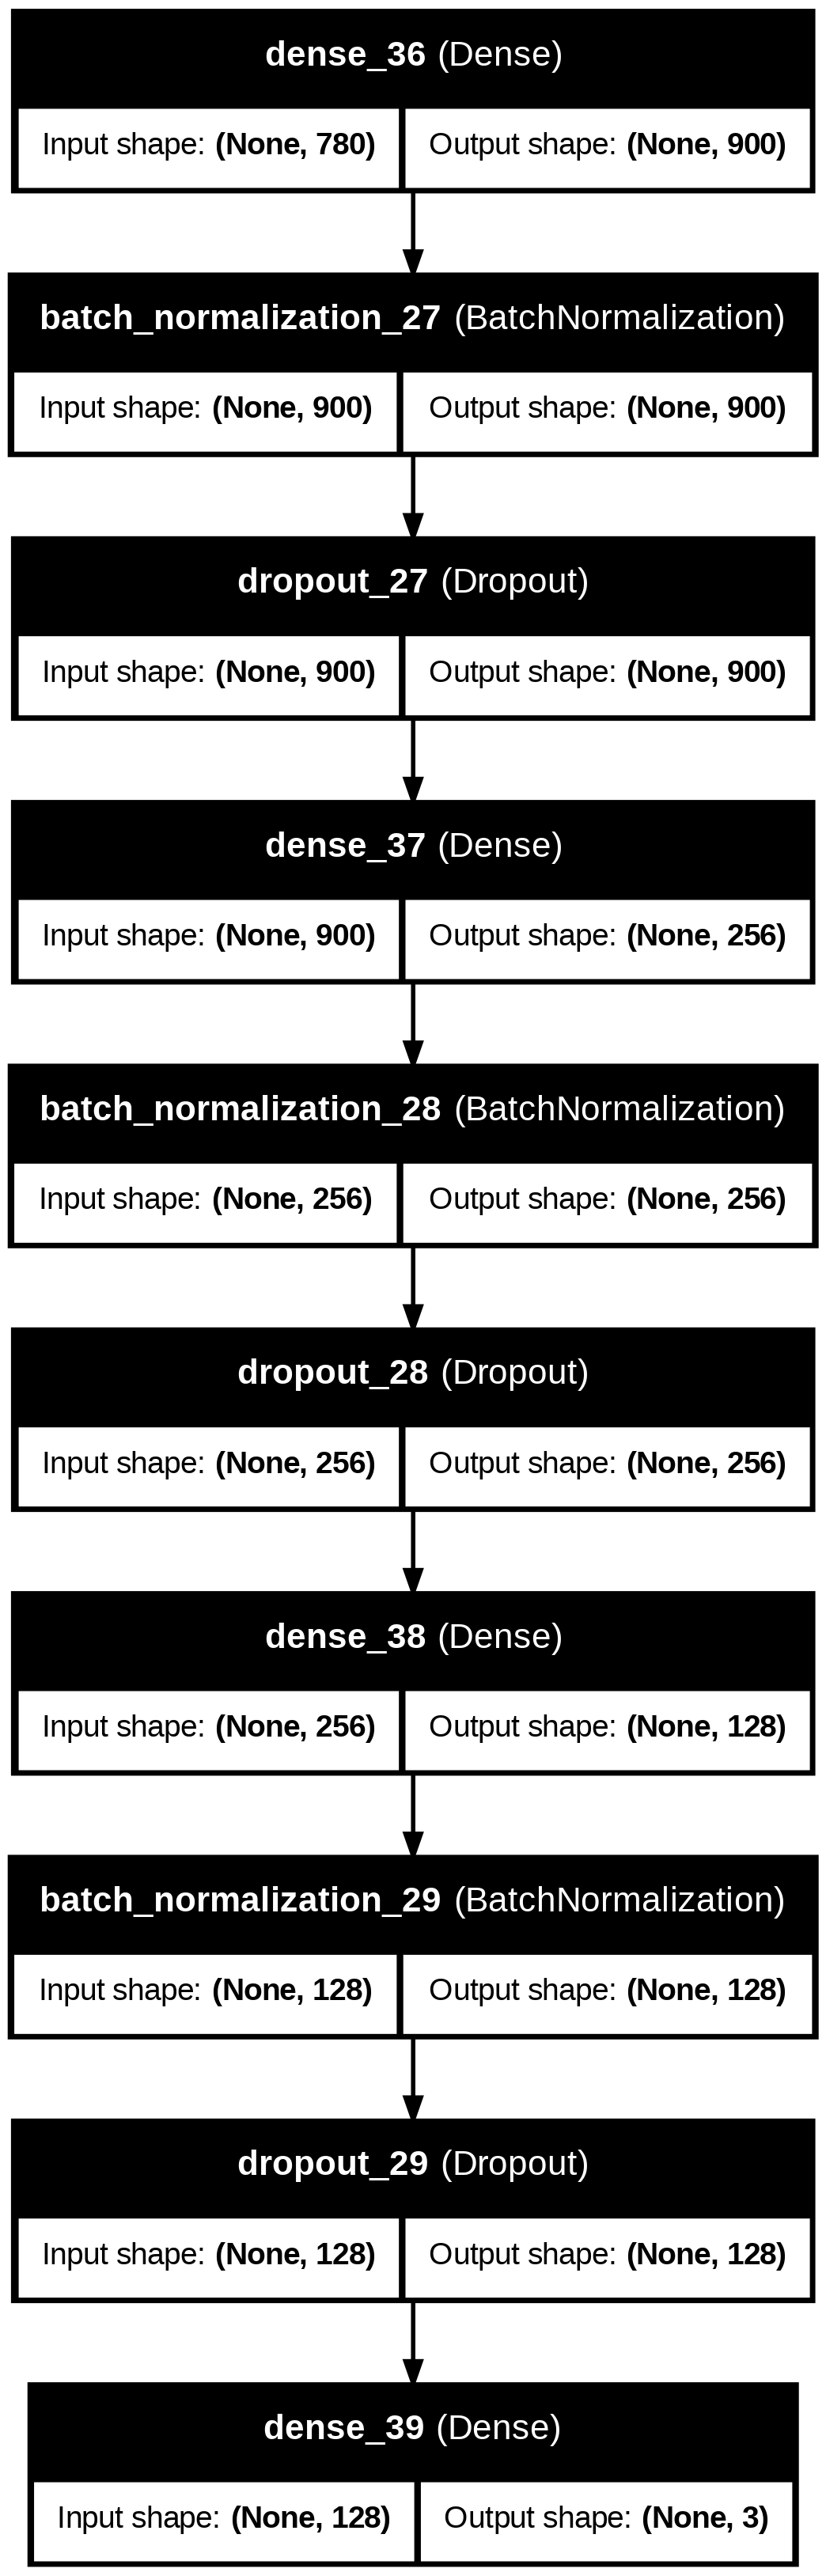

In [59]:
keras.utils.plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

In [60]:
# ## -- MODEL EVALUATION FROM LAST TRAINER --
# print('========= EVALUATE BEST MODEL')
# inference_model_to_eval = keras.models.load_model(f"{CHECKPOINT}infer_model_1.keras")

# # Re-compile the loaded model to enable evaluation
# inference_model_to_eval.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=LR),
#     loss='binary_crossentropy',
#     metrics=[
#         keras.metrics.AUC(name='auc')
#     ]
# )

# inference_model_to_eval.evaluate(result['val_data'][0])

In [61]:
# 'submit_keras_V0_[768, 256, 128]97667.csv'

In [62]:
## -- PLOTTING RESULTS --
def plot_results(history, plot_dict=None):
    list_ = list(plot_dict.keys())
    val_loss = 'val_' + plot_dict[list_[0]]
    val_acc  = 'val_' + plot_dict[list_[1]]
    for i, data in tqdm(enumerate(histories), total=len(histories)):
        loss_results = pd.DataFrame({plot_dict[list_[0]]: data[plot_dict[list_[0]]], val_loss: data[val_loss]})
        acc_results = pd.DataFrame({plot_dict[list_[1]]: data[plot_dict[list_[1]]], val_acc: data[val_acc]})
    
        plt.figure(figsize=(18, 5))
        marker = 'o'
    
        ## -- PLOT 1: LOSS --
        plt.subplot(121)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results[plot_dict[list_[0]]], label='train', marker=marker)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results[val_loss], label='valid', marker=marker)
        plt.title(plot_dict[list_[0]], fontweight='semibold')
        plt.xlabel('Epochs')
        plt.ylabel(plot_dict[list_[0]])
    
        ## -- PLOT 2: ACCURACY --
        plt.subplot(122)
        sns.lineplot(acc_results, x=acc_results.index, y=acc_results[plot_dict[list_[1]]], label='train', marker=marker)
        sns.lineplot(acc_results, x=acc_results.index, y=acc_results[val_acc], label='valid', marker=marker)
        plt.title(plot_dict[list_[1]], fontweight='semibold')
        plt.xlabel('Epochs')
        plt.ylabel(plot_dict[list_[1]])
    
        stat_ = f"fold_score: {result['scores'][0][i]:.5f}"
        plt.scatter(x=0, y=0, label=stat_, color='k')
    
        plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold', color='b')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()
        print()

print('Plot function ready')

Plot function ready


  0%|          | 0/10 [00:00<?, ?it/s]

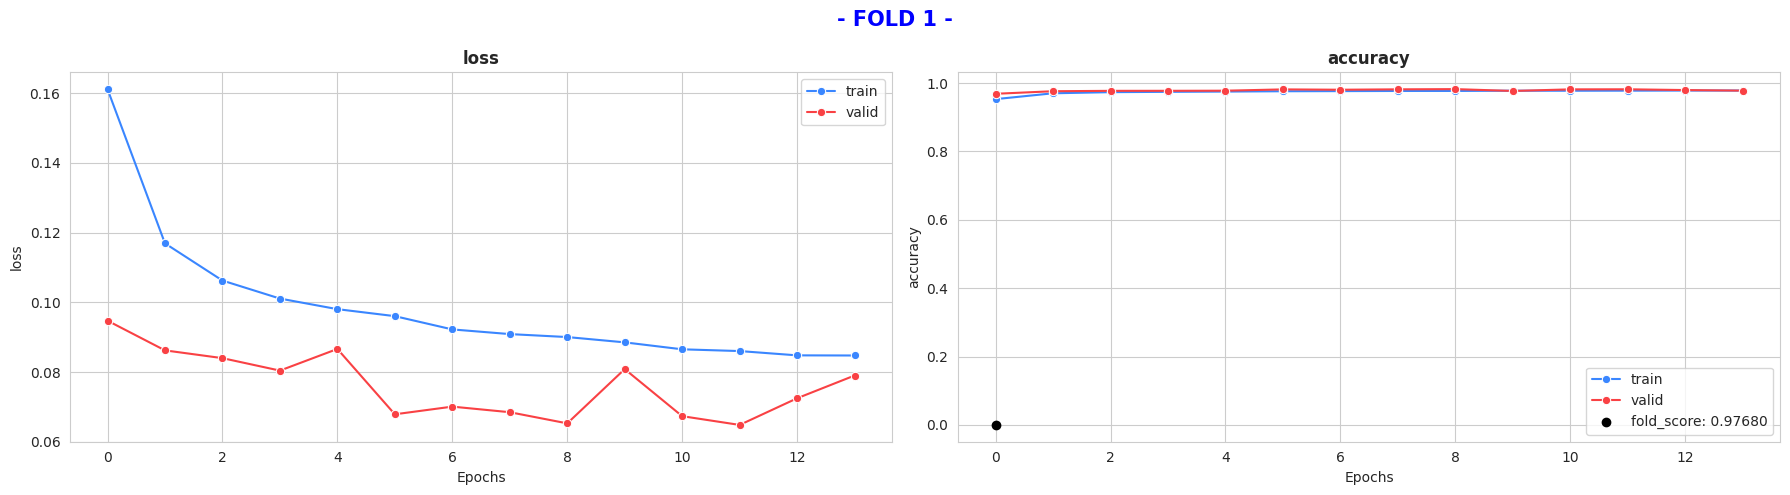

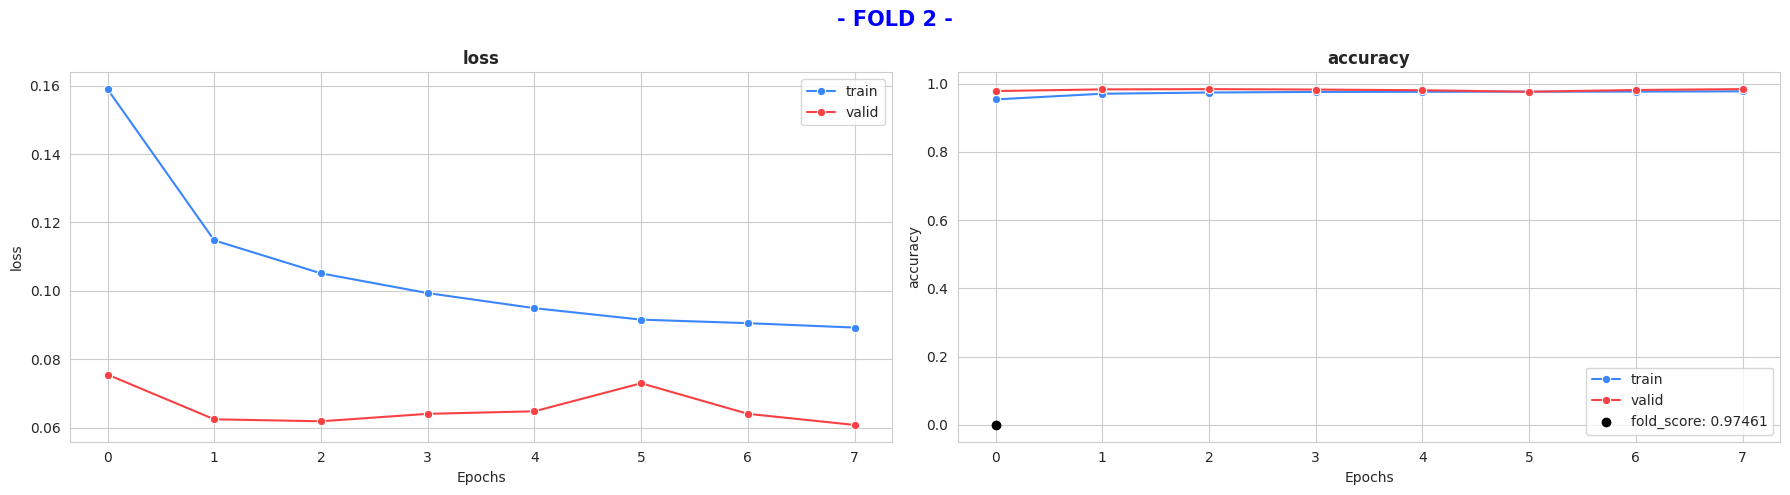

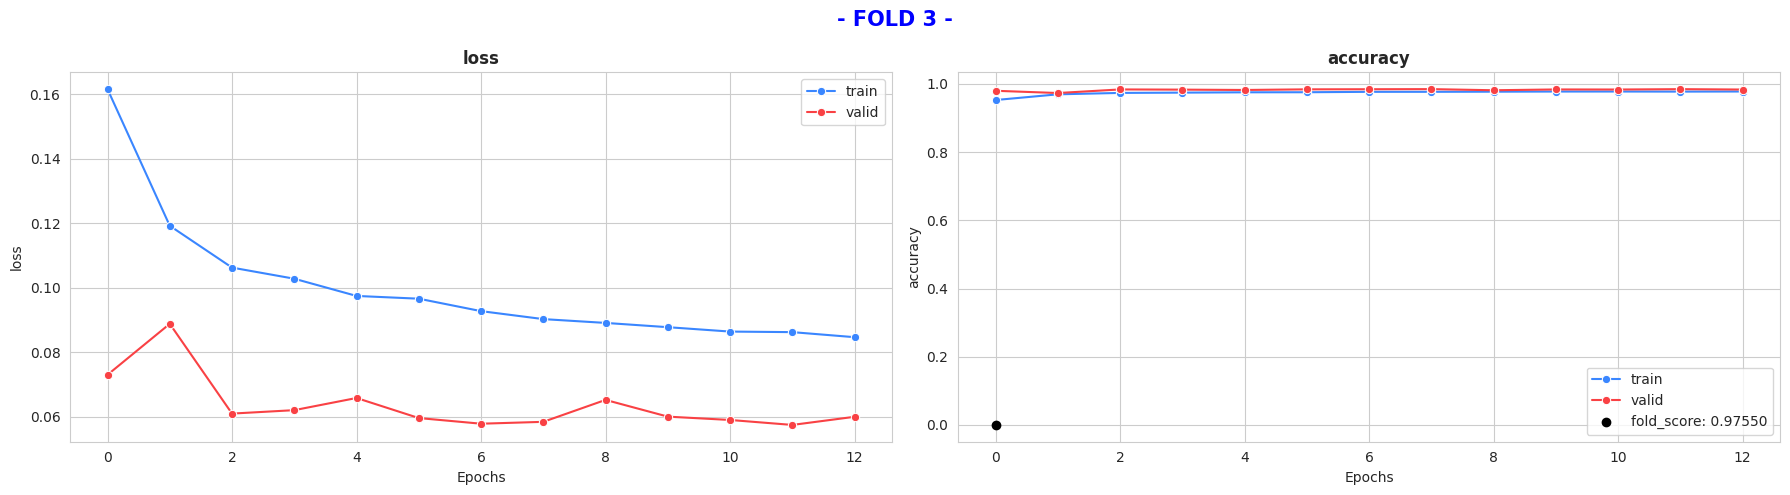

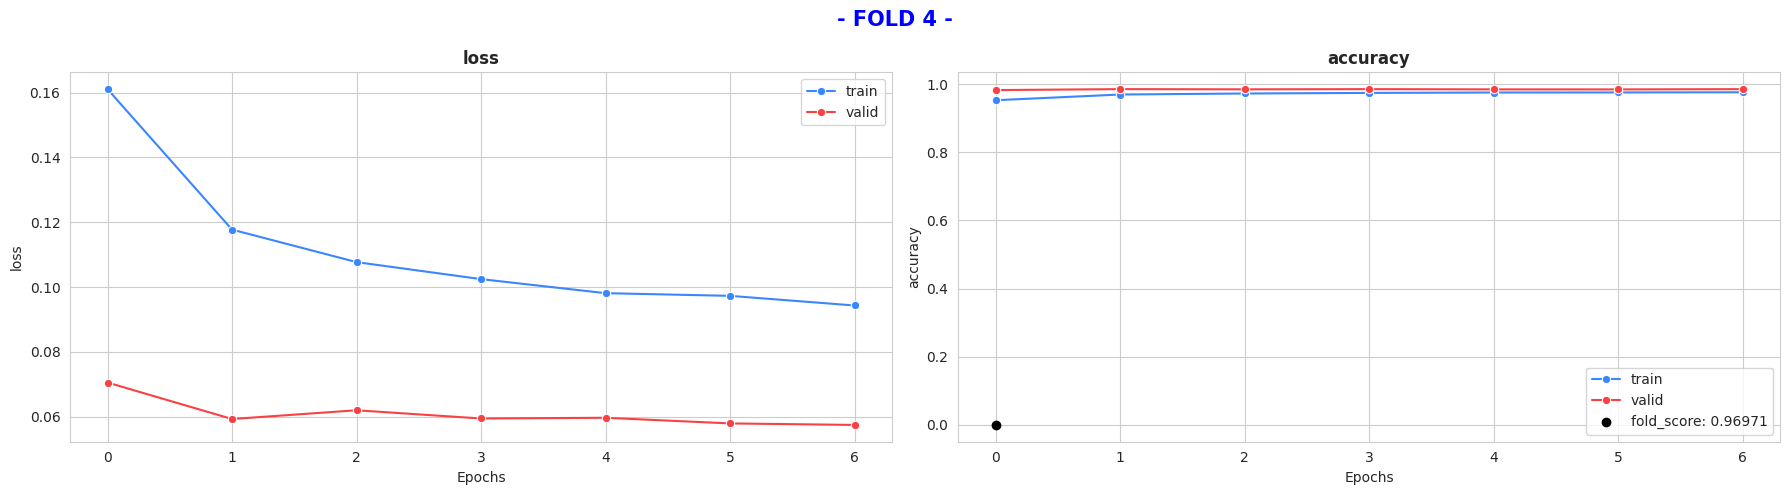

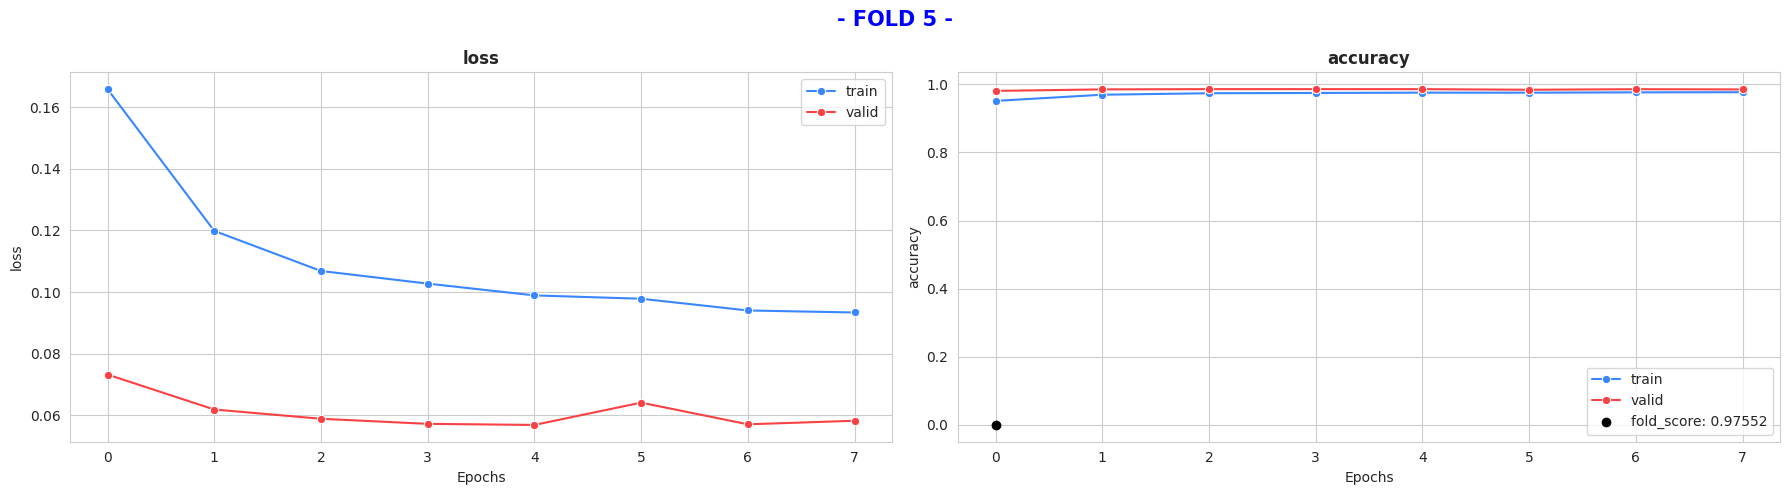

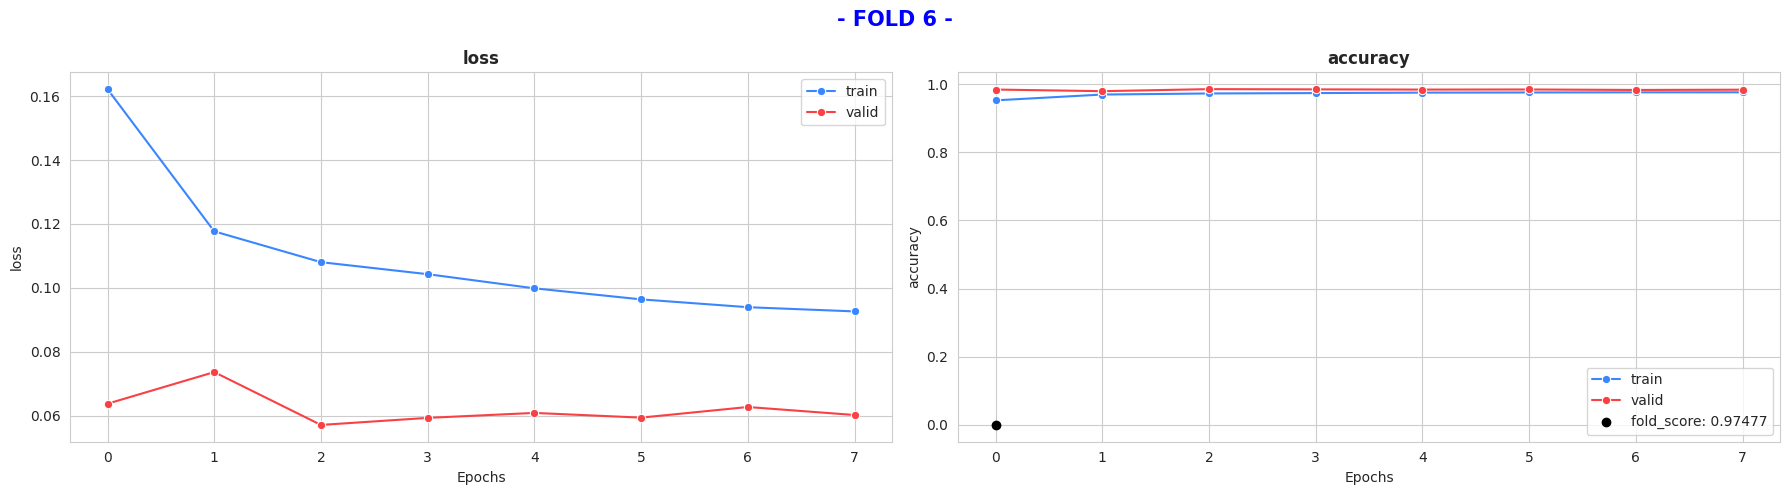

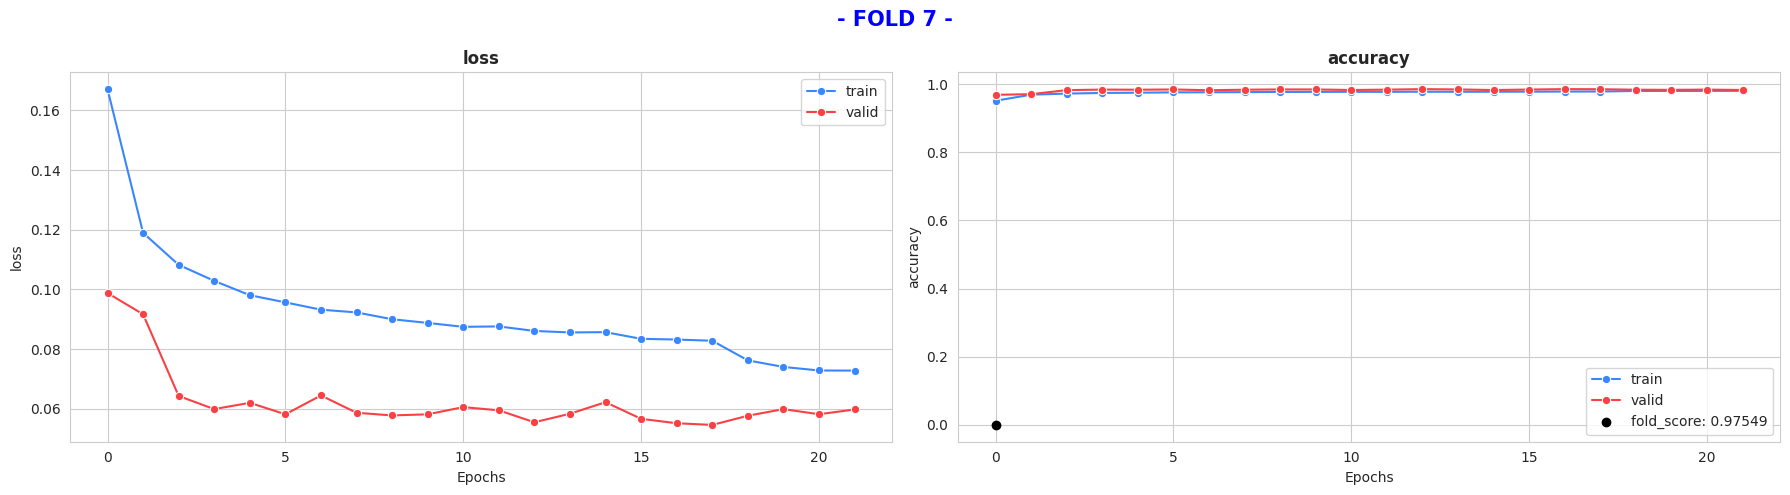

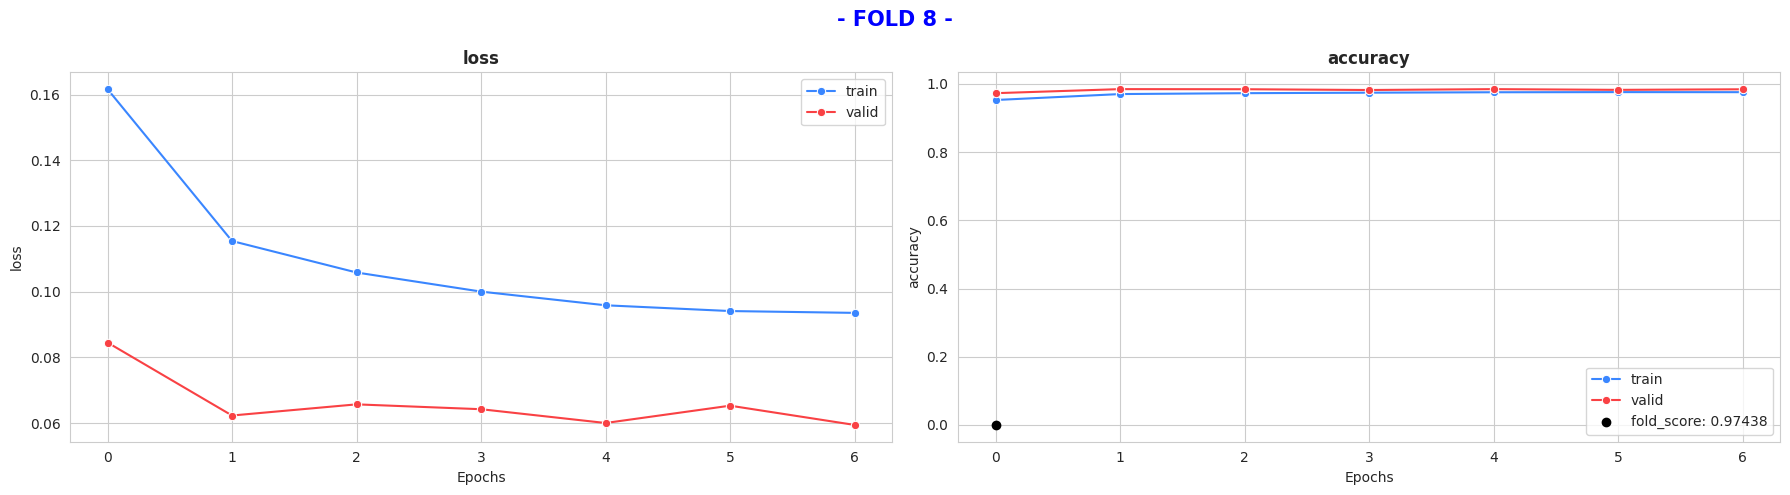

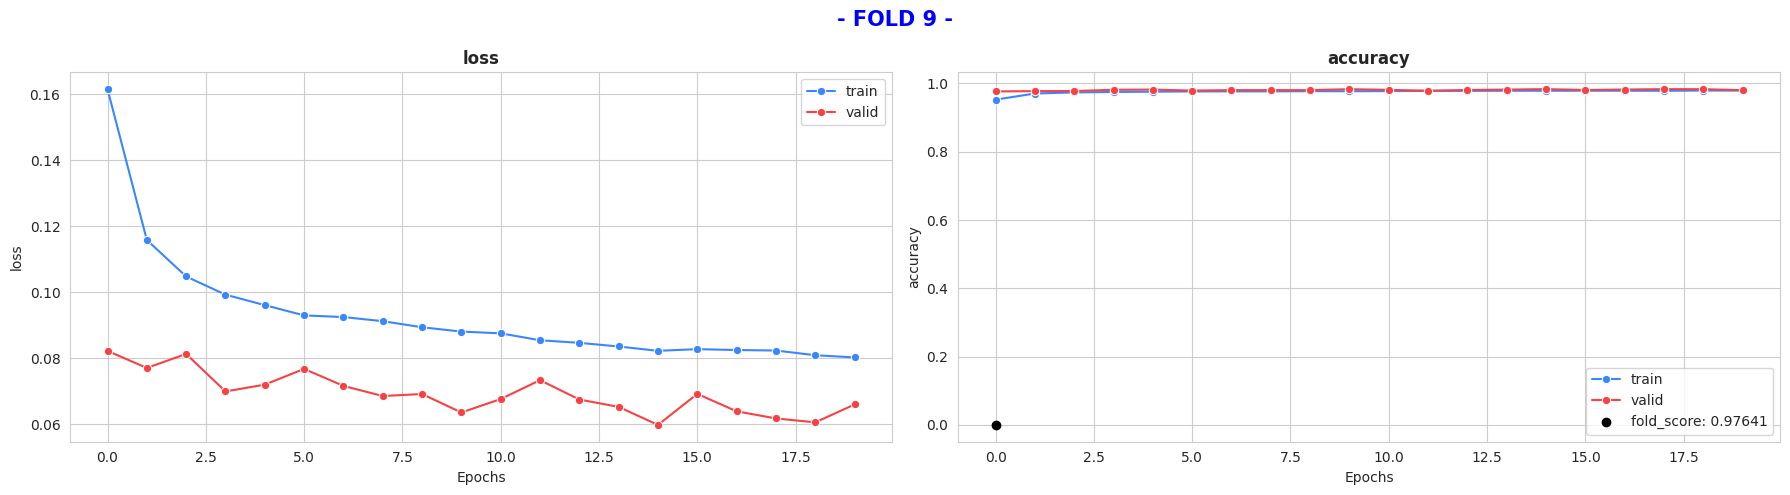

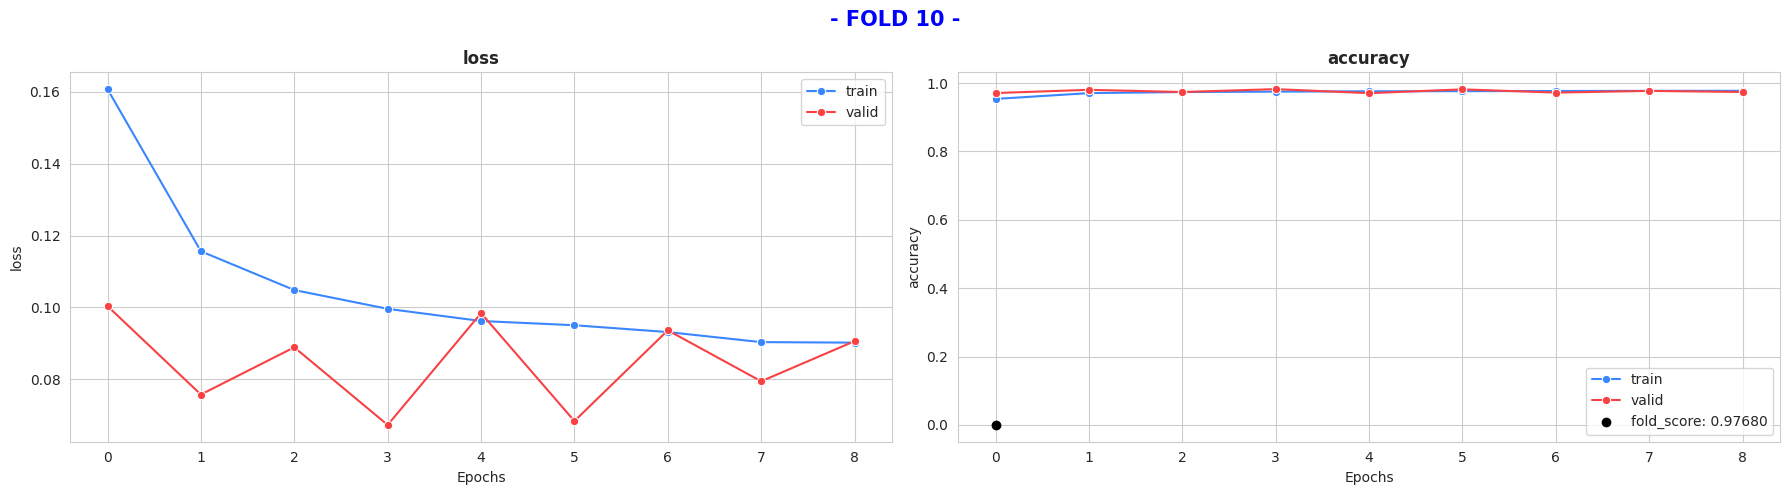

In [63]:
histories = result['history']
plot_dict = {'loss': 'loss', 'acc': 'accuracy'}

plot_results(histories, plot_dict=plot_dict)

In [64]:
## -- Save BASE predictions/submission --
n = version_name + 'base_' + str(result['final_score'][0]).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'][0])
np.save(f'test_{n}.npy', result['test_preds'][0])

file_name = f"submit_{n}.csv"
submit[TARGET] = pd.Series(np.argmax(result['test_preds'][0], axis=1)).map(mapping_r)
submit.to_csv(file_name, index=False)

print(f"Submission file exported as: {file_name}\n")
submit.head(10)

Submission file exported as: submit_keras_V0_venn_all_base_975.csv



,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


In [65]:
## -- Save CALIBRATED predictions/submission --
n = version_name + 'calib_' + str(result['final_score'][1]).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'][1])
np.save(f'test_{n}.npy', result['test_preds'][1])

file_name = f"submit_{n}.csv"
submit[TARGET] = pd.Series(np.argmax(result['test_preds'][1], axis=1)).map(mapping_r)
submit.to_csv(file_name, index=False)

print(f"Submission file exported as: {file_name}\n")
submit.head(10)

Submission file exported as: submit_keras_V0_venn_all_calib_97241.csv



,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


In [66]:
# ## -- PLOTTING RESULTS --
# for i, data in tqdm(enumerate(histories), total=len(histories)):
#     loss_results = pd.DataFrame({'loss': data['loss'], 'val_loss': data['val_loss']})
#     acc_results = pd.DataFrame({'accuracy': data['accuracy'], 'val_accuracy': data['val_accuracy']})

#     plt.figure(figsize=(18, 5))
#     marker = 'o'

#     ## -- PLOT 1: LOSS --
#     plt.subplot(121)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.loss, label='train', marker=marker)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='valid', marker=marker)
#     plt.title('Multi_Loss', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('multi_loss')

#     ## -- PLOT 2: ACCURACY --
#     plt.subplot(122)
#     sns.lineplot(acc_results, x=acc_results.index, y=acc_results.accuracy, label='train', marker=marker)
#     sns.lineplot(acc_results, x=acc_results.index, y=acc_results.val_accuracy, label='valid', marker=marker)
#     plt.title('Balanced_Accuracy', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('balanced_accuracy')

#     stat_ = f"fold_score: {result['scores'][i]:.5f}"
#     plt.scatter(x=0, y=0, label=stat_, color='k')

#     plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold', color='b')
#     plt.legend(loc='best')
#     plt.tight_layout()
#     plt.show()
#     print()